# **DETECTING ADVERSE DRUG REACTION SIGNALS FROM WEBMD REVIEWS USING NLP, MACHINE LEARNING AND DEEP LEARNING**

# **Project Objective**

The objective of this project is to analyze WebMD patient drug reviews, extract patient-reported adverse drug reactions, compare them with listed official side effects, and classify each review into one of three ADR categories: Known ADR, Potential ADR Signal, or No ADR Mention and build machine learning and deep learning models to predict the ADR category of patient reviews.

# **Variables**

**Age**	- Age group of the patient who wrote the review.

**Condition**	- Medical condition or disease the patient is taking the drug for.

**Date** - Date when the patient submitted the review.

**Drug**	- Name of the medication being reviewed .

**DrugId** 	- Unique identifier assigned to each drug in the dataset.

**EaseofUse**	- Patient's rating of how easy the medication was to use, usually on a scale of 1-5 (5 = very easy to use).

**Effectiveness**	- Patient's rating of how effective the medication was, usually on a scale of 1-5 (5 = very effective).

**Reviews**	- text review where the patient describes their experience with the medication. This is your main NLP feature.

**Satisfaction** - Overall satisfaction rating given by the patient, usually on a scale of 1-5 (5 = very satisfied).

**Sex**	- Patient's gender (Male or Female).

**Sides**	- Official side effects listed for the medication on WebMD. In the project, this is used as the reference (ground truth) to compare with the side effects extracted from patient reviews.

**UsefulCount**	- Number of users who marked the review as helpful or useful. Higher values indicate the review was considered more informative by other users.





# **INSTALL LIBRARIES**

In [ ]:
# Install the required Python libraries
!pip install nltk contractions rapidfuzz wordcloud -q
import pandas as pd #for data handling
import numpy as np #for data handling
import re # text cleaning using regular expressions
import nltk #Natural Language Toolkit (NLTK) for text preprocessing
import contractions # expand contractions
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import tensorflow as tf
!pip install shap -q
import shap

warnings.filterwarnings("ignore")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.1 MB/s eta 0:00:00


In [ ]:
from nltk.corpus import stopwords # Import stop words
from nltk.stem import WordNetLemmatizer, PorterStemmer # for reducing words to their base form
from collections import Counter # Counter to count word frequencies
from rapidfuzz import fuzz #for fuzzy text matching
from wordcloud import WordCloud # visualize the most common words
!pip install spacy -q  #advanced natural language processing
import spacy
from tensorflow import keras

In [ ]:
# Scikit-learn imports
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.utils import resample

In [ ]:
# Download the required NLTK resources
nltk.download("stopwords", quiet = True)
nltk.download("wordnet", quiet = True)
nltk.download("omw-1.4", quiet = True)

# Display all columns when viewing a DataFrame
pd.set_option("display.max_columns", None)

# **DATA LOADING AND EXPLORATION**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving webmd.csv to webmd.csv


In [ ]:
# Load the WebMD dataset
file_path = "/content/webmd.csv"
df = pd.read_csv(file_path)

# Show the first five rows of the dataset
df.head()

,Age,Condition,Date,Drug,DrugId,EaseofUse,Effectiveness,Reviews,Satisfaction,Sex,Sides,UsefulCount
0,75 or over,Stuffy Nose,9/21/2014,25dph-7.5peh,146724,5,5,I'm a retired physician and of all the meds I ...,5,Male,"Drowsiness, dizziness , dry mouth /nose/thro...",0
1,25-34,Cold Symptoms,1/13/2011,25dph-7.5peh,146724,5,5,cleared me right up even with my throat hurtin...,5,Female,"Drowsiness, dizziness , dry mouth /nose/thro...",1
2,65-74,Other,7/16/2012,warfarin (bulk) 100 % powder,144731,2,3,why did my PTINR go from a normal of 2.5 to ov...,3,Female,,0
3,75 or over,Other,9/23/2010,warfarin (bulk) 100 % powder,144731,2,2,FALLING AND DON'T REALISE IT,1,Female,,0
4,35-44,Other,1/6/2009,warfarin (bulk) 100 % powder,144731,1,1,My grandfather was prescribed this medication ...,1,Male,,1


The dataset contains 36,2806 rows and 12 columns.

In [ ]:
# Display the number of rows and columns in the dataset
print("Rows and Columns:", df.shape)

# Display the names of all columns
print("\nColumn Names:")
print(df.columns.tolist())

# Display the data type of each column
print("\nData Types:")
print(df.dtypes)

Rows and Columns: (362806, 12)

Column Names:
['Age', 'Condition', 'Date', 'Drug', 'DrugId', 'EaseofUse', 'Effectiveness', 'Reviews', 'Satisfaction', 'Sex', 'Sides', 'UsefulCount']

Data Types:
Age              object
Condition        object
Date             object
Drug             object
DrugId            int64
EaseofUse         int64
Effectiveness     int64
Reviews          object
Satisfaction      int64
Sex              object
Sides            object
UsefulCount       int64
dtype: object


# **Missing Values**

In [ ]:
# Convert empty strings and the text "nan" to actual missing values
str_cols = ['Age', 'Condition', 'Drug', 'Reviews', 'Sex', 'Sides']

for c in str_cols:
    df[c] = df[c].astype(str).str.strip()
    df[c] = df[c].replace({'': np.nan, 'nan': np.nan})
# Check for missing values in each column
missing_table = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percent": round((df.isnull().sum() / len(df)) * 100, 4)})

# Sort the columns by the percentage of missing values
missing_table = missing_table.sort_values("Missing Percent", ascending=False)

# Display the missing value summary
display(missing_table)

,Missing Count,Missing Percent
Reviews,41889,11.5458
Sex,26537,7.3144
Sides,17460,4.8125
Age,12202,3.3632
Condition,43,0.0119
Date,0,0.0000
Drug,0,0.0000
DrugId,0,0.0000
Effectiveness,0,0.0000
EaseofUse,0,0.0000


The table shows the number and percentage of missing values in each column. The Reviews column has the highest number of missing values (41,889, or 11.55%), followed by Sex (26,537, or 7.31%), Sides (17,460, or 4.81%), and Age (12,202, or 3.36%). The Condition column has only 43 missing values (0.01%), while the remaining columns have no missing values.

# **Duplicate Rows**

In [ ]:
# Duplicate rows
duplicate_count = df.duplicated().sum()

print("Duplicate Rows:", duplicate_count)
df = df.drop_duplicates()

Duplicate Rows: 944


# **Unique Values**

In [ ]:
# Count the number of unique values in selected categorical columns
for col in ["Age", "Sex", "Drug", "Condition", "Sides"]:
    print(f"\n{col}")
    print(df[col].nunique())
#unique values iN age column
print("Unique age values:")
sorted(df["Age"].astype(str).unique())


Age
11

Sex
2

Drug
7093

Condition
1805

Sides
1649
Unique age values:


['0-2',
 '13-18',
 '19-24',
 '25-34',
 '3-6',
 '35-44',
 '45-54',
 '55-64',
 '65-74',
 '7-12',
 '75 or over',
 'nan']

The output shows the number of unique values in the selected categorical columns. The Age column has 11 unique groups, Sex has 2 categories. The Drug column contains 7,093 unique drug names, Condition has 1,805 different medical conditions, and Sides has 1,649 unique side effect descriptions.

In [ ]:
print(df.columns.tolist())

['Age', 'Condition', 'Date', 'Drug', 'DrugId', 'EaseofUse', 'Effectiveness', 'Reviews', 'Satisfaction', 'Sex', 'Sides', 'UsefulCount']


In [ ]:
# Display the unique rating values for each rating column
for col in ["EaseofUse", "Effectiveness", "Satisfaction"]:
    print(f"{col} values:", list(map(int,sorted(df[col].dropna().unique()))))

EaseofUse values: [1, 2, 3, 4, 5, 6, 10]
Effectiveness values: [1, 2, 3, 4, 5, 6, 10]
Satisfaction values: [1, 2, 3, 4, 5, 6, 10]


# **DATA CLEANING AND PREPROCESSING**

**Standardise Column Nmes**

In [ ]:
# Standardize the column names for consistency
df.columns = (
    df.columns
    .str.strip()  # Remove extra spaces
    .str.replace(" ", "_") # Replace spaces with underscores
    .str.replace("-", "_") # Replace hyphens with underscores
    .str.lower()   # Convert all column names to lowercase
)
# Display the updated column names
print(df.columns.tolist())

['age', 'condition', 'date', 'drug', 'drugid', 'easeofuse', 'effectiveness', 'reviews', 'satisfaction', 'sex', 'sides', 'usefulcount']


**Standardise Column Values**

In [ ]:
# Standardize the values in categorical columns
df["age"] = df["age"].astype(str).str.strip()                 # Remove extra spaces
df["sex"] = df["sex"].astype(str).str.strip().str.title()     # Standardize text format
df["condition"] = df["condition"].astype(str).str.strip().str.title()  # Standardize text format
df["drug"] = df["drug"].astype(str).str.strip().str.lower()   # Convert drug names to lowercase
df["drug"] = df["drug"].str.replace(r"\s+", " ", regex=True)  # Remove extra spaces between words

# Display the cleaned categorical columns
df[["age", "sex", "condition", "drug"]].head()

,age,sex,condition,drug
0,75 or over,Male,Stuffy Nose,25dph-7.5peh
1,25-34,Female,Cold Symptoms,25dph-7.5peh
2,65-74,Female,Other,warfarin (bulk) 100 % powder
3,75 or over,Female,Other,warfarin (bulk) 100 % powder
4,35-44,Male,Other,warfarin (bulk) 100 % powder


The Sex and Condition columns were converted to title case, while the Drug column was converted to lowercase and extra spaces between words were removed. This means similar values now have a consistent format, which helps reduce duplicate categories and improves the quality of the data for analysis and machine learning.

**Clean the age column**

In [ ]:
# Replace the text "nan" with a missing value
df["age"] = df["age"].replace(["Nan", "nan", "None", "none", ""], np.nan)

# Fill missing values with "Unknown"
df["age"] = df["age"].fillna("Unknown")

# Verify the cleaned age values
print("Age values after cleaning:")
print(sorted(df["age"].unique()))

Age values after cleaning:
['0-2', '13-18', '19-24', '25-34', '3-6', '35-44', '45-54', '55-64', '65-74', '7-12', '75 or over', 'Unknown']


**Handle invalid rating**

In [ ]:
# Remove records with invalid rating values
rating_cols = ["easeofuse", "effectiveness", "satisfaction"]

# Keep only rows where all rating values are 5 or below
df = df[~(df[rating_cols] > 5).any(axis=1)]

This step removes records that contain invalid rating values. The Ease of Use, Effectiveness, and Satisfaction columns are expected to have ratings between 1 and 5, so any row with a value greater than 5 is removed.

**Handle missing Values**

In [ ]:
# Remove records with missing or empty review text
df = df.dropna(subset=["reviews"])

# Convert the review column to text
df["reviews"] = df["reviews"].astype(str)

# Remove rows with blank reviews
df = df[df["reviews"].str.strip() != ""]

# Remove rows where the review contains the text "nan"
df = df[df["reviews"].str.lower() != "nan"]

Missing values, blank reviews, and reviews that contain only the text "nan" are removed from the dataset.

In [ ]:
# Fill missing side effect values with a default value
df["sides"] = df["sides"].fillna("No side effects listed").astype(str)

This step fills the missing values in the side column with the text "No side effects listed".

In [ ]:
# Convert selected columns to numeric values
for col in ["easeofuse", "effectiveness", "satisfaction", "usefulcount"]:
    # Convert invalid values to missing values (NaN)
    df[col] = pd.to_numeric(df[col], errors="coerce")

    # Fill missing values with the median of the column
    df[col] = df[col].fillna(df[col].median())

This step converts the selected columns to numeric values.If any invalid values are found, they are converted to missing values (NaN) and then replaced with the median of the corresponding column. This means all selected columns contain valid numeric values, reducing missing data while preserving the overall distribution of the dataset.

In [ ]:
#handle sex column
# Replace text values that represent missing data
df["sex"] = df["sex"].replace(["Nan", "nan", "None", "none", ""], np.nan)
# Fill missing values with "Unknown"
df["sex"] = df["sex"].fillna("Unknown")

#Handle condition column
# Replace text values that represent missing data
df["condition"] = df["condition"].replace(["Nan", "nan", "None", "none", ""], np.nan)
# Fill missing values with "Unknown"
df["condition"] = df["condition"].fillna("Unknown")

This step replaces missing values in the sex, and condition columns with the label "Unknown".

**Handle date Column**

In [ ]:
# Convert the date column to datetime format
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Extract the year and month from the date
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

# Verify the data type of the date column
print(df["date"].dtype)

datetime64[ns]


The above step converts the date column into a datetime format.It then creates two new features, year and month, by extracting them from the date.

In [ ]:
print("After Cleaning:", df.shape)
df.isnull().sum()

After Cleaning: (320094, 14)


,0
age,0
condition,0
date,0
drug,0
drugid,0
easeofuse,0
effectiveness,0
reviews,0
satisfaction,0
sex,0


In [ ]:
#view dataset after cleaning
df.head()

,age,condition,date,drug,drugid,easeofuse,effectiveness,reviews,satisfaction,sex,sides,usefulcount,year,month
0,75 or over,Stuffy Nose,2014-09-21,25dph-7.5peh,146724,5,5,I'm a retired physician and of all the meds I ...,5,Male,"Drowsiness, dizziness , dry mouth /nose/thro...",0,2014,9
1,25-34,Cold Symptoms,2011-01-13,25dph-7.5peh,146724,5,5,cleared me right up even with my throat hurtin...,5,Female,"Drowsiness, dizziness , dry mouth /nose/thro...",1,2011,1
2,65-74,Other,2012-07-16,warfarin (bulk) 100 % powder,144731,2,3,why did my PTINR go from a normal of 2.5 to ov...,3,Female,No side effects listed,0,2012,7
3,75 or over,Other,2010-09-23,warfarin (bulk) 100 % powder,144731,2,2,FALLING AND DON'T REALISE IT,1,Female,No side effects listed,0,2010,9
4,35-44,Other,2009-01-06,warfarin (bulk) 100 % powder,144731,1,1,My grandfather was prescribed this medication ...,1,Male,No side effects listed,1,2009,1


# **DESCRIPTIVE STATISTICS**

In [ ]:
# Display descriptive statistics for the main numeric features
numeric_cols = ["easeofuse","effectiveness","satisfaction","usefulcount"]
df[numeric_cols].describe().round(2)

,easeofuse,effectiveness,satisfaction,usefulcount
count,320094.00,320094.00,320094.00,320094.00
mean,4.00,3.51,3.06,7.43
std,1.34,1.48,1.63,9.66
min,1.00,1.00,1.00,0.00
25%,3.00,2.00,1.00,1.00
50%,5.00,4.00,3.00,4.00
75%,5.00,5.00,5.00,10.00
max,5.00,5.00,5.00,255.00


- Dataset contains 320,094 records with no missing values in the selected numeric columns.
- Average Ease of Use rating is 4.00, indicating that users generally found the medications easy to use.
- The average Effectiveness rating is 3.51, meaning that users rated the medications as moderately effective.
- The average Satisfaction rating is 3.06, which is slightly lower than the ease of use and effectiveness ratings.
- All three rating variables range from 1 to 5, confirming that the values are within the expected rating scale.
- The average Useful Count is 7.43, with a median of 4, meaning that most reviews received only a few useful votes.
- The maximum Useful Count is 255, indicating that a small number of reviews were considered highly useful by many users.
- The Useful Count has a larger standard deviation (9.66) than the rating variables, showing greater variation in how useful different reviews were considered.

# **NLP PREPROCESSING**

**Create the stop word list**

Words like "no", "not", "never", and "without" are kept because they change the meaning of a sentence.Keeping these negation words helps preserve the correct meaning of the reviews and improves the accuracy of adverse drug reaction (ADR) detection.

In [ ]:
# Load the English stop words
stop_words = set(stopwords.words("english"))

# Keep important words that may indicate adverse drug reactions
keep_words = {"no", "not", "nor", "never","none", "without", "but", "however"}

# Remove the important words from the stop word list
stop_words = stop_words - keep_words

**Create the lemmatizer**

The lemmatizer converts words to their base form.This reduces different forms of the same word to one common form.
Helps group similar words together during NLP.

In [ ]:
lemmatizer = WordNetLemmatizer()

**Define the preprocessing function**

This code Creates a reusable function called preprocess_nlp().
The function defines all the text-cleaning steps.This section performs the actual NLP preprocessing.
- converts text to lowercase,
- expands contractions,
- removes punctuation and numbers,
- removes extra spaces,
- splits text into words,
- removes stop words,
- keeps important negation words,
- lemmatizes each word,
- joins the cleaned words back into a sentence.

In [ ]:
# Function to preprocess text for NLP
def preprocess_nlp(text):

    # Return an empty string if the value is not text
    if not isinstance(text, str):
        return ""

    # Convert text to lowercase
    text = text.lower()

    # Expand contractions (e.g., "don't" → "do not")
    text = contractions.fix(text)

    # Remove numbers and special characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Split the text into individual words
    tokens = text.split()

    # Remove stop words, keep important negation words, and lemmatize words
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 1
    ]

    # Join the cleaned words back into a sentence
    return " ".join(tokens)

**Apply the function**

Applies the preprocessing function to the reviews column and  sides column to create cleaned text for NLP analysis. It also calculates the number of words in each cleaned review and displays the original and processed text to verify that the preprocessing was applied successfully.

In [ ]:
# Apply preprocessing to the review and side effect text
df["review_nlp"] = df["reviews"].apply(preprocess_nlp)
df["side_nlp"] = df["sides"].apply(preprocess_nlp)

# Display the processed text
df[["reviews", "review_nlp", "sides","side_nlp"]].head()

,reviews,review_nlp,sides,side_nlp
0,I'm a retired physician and of all the meds I ...,retired physician med tried allergy seasonal n...,"Drowsiness, dizziness , dry mouth /nose/thro...",drowsiness dizziness dry mouth nose throat hea...
1,cleared me right up even with my throat hurtin...,cleared right even throat hurting went away ta...,"Drowsiness, dizziness , dry mouth /nose/thro...",drowsiness dizziness dry mouth nose throat hea...
2,why did my PTINR go from a normal of 2.5 to ov...,ptinr go normal,No side effects listed,no side effect listed
3,FALLING AND DON'T REALISE IT,falling not realise,No side effects listed,no side effect listed
4,My grandfather was prescribed this medication ...,grandfather prescribed medication coumadin ass...,No side effects listed,no side effect listed


The output shows the original review, the cleaned review (review_nlp), and the cleaned side effect text (side_nlp). The cleaned text contains only meaningful words after removing unnecessary words and symbols.

# **Built Official Side Effect Vocabulary from Side Column**

**Define boilerplate patterns**

In [ ]:
#Creates a list of common phrases that do not describe side effects,
BOILERPLATE_PATTERNS = [
    r"\btell your doctor\b[^.,;]*[.,;]?",
    r"\bcontact your doctor\b[^.,;]*[.,;]?",
    r"\bnotify your doctor\b[^.,;]*[.,;]?",
    r"\bconsult your doctor\b[^.,;]*[.,;]?",
    r"\bseek medical attention\b[^.,;]*[.,;]?",
    r"\bin case of overdose\b[^.,;]*[.,;]?",
    r"\bpharmacist promptly\b[^.,;]*[.,;]?",
    r"\bpersists or worsens?\b[^.,;]*[.,;]?"
]

The above phrases will be removed because they are standard medical instructions and are not actual adverse drug reactions.This removes only the instruction, not everything after it.

**Define the expand_slash() function**

Expands side effects written with slashes into separate terms.It identifies shared prefixes or suffixes and reconstructs complete side-effect names (e.g., "dry mouth/nose/throat" becomes "dry mouth", "dry nose", and "dry throat"). This improves the accuracy of ADR extraction by ensuring each side effect is processed individually.

In [ ]:
# Expand side effects written with slashes into separate terms
def expand_slash(segment):

    # Return the original text if no slash is present
    if "/" not in segment:
        return [segment]

    # Split the text at each slash and remove extra spaces
    parts = [p.strip() for p in segment.split("/") if p.strip()]

    # Return the parts if there is only one item
    if len(parts) < 2:
        return parts

    # Split the first and last parts into individual words
    first_words = parts[0].split()
    last_words = parts[-1].split()

    # Expand terms that share the same ending word
    if len(first_words) >= 2 and len(last_words) > 1:
        suffix = last_words[-1]
        return [
            p if i == len(parts) - 1 else f"{p} {suffix}"
            for i, p in enumerate(parts)
        ]

    # Expand terms that share the same beginning words
    if len(first_words) > 1 and len(last_words) == 1:
        prefix = " ".join(first_words[:-1])
        return [
            p if i == 0 else f"{prefix} {p}"
            for i, p in enumerate(parts)
        ]

    # Return the split terms if no expansion is needed
    return parts

**Define filler phrases**


Common filler phrases such as "may occur" and "you may experience" are identified and removed because they do not represent actual side effects.

In [ ]:
# Common filler phrases that are not side effects
FILLER_PHRASES = [
    r"\byou may experience\b",
    r"\bmay occur\b",
    r"\bmay happen\b",
    r"\bmay develop\b",
    r"\bas your body adjusts\b",
    r"\bwhile your body adjusts\b",
    r"\bwhen starting this medication\b",
    r"\bduring treatment\b"
]


The below code removes medical filler phrases, expands slash-separated side effects into individual terms, and returns a standardized list of side effects for accurate ADR matching.

**Parse official side effects**

The parse_side_effects() function is the main preprocessing function for sides column. It removes medical instructions and filler phrases, expands slash-separated side effects, cleans the text, and returns a standardized list of side effects for each drug.

In [ ]:
# Parse and clean the official side effects listed for each drug
def parse_side_effects(text):

    # Convert text to lowercase
    text = str(text).lower().strip()

    # Ignore empty values or records with no side effects
    if text == "" or "no side effects" in text:
        return []

    # Remove text inside brackets
    text = re.sub(r"\(.*?\)", "", text)

    # Remove common instructional phrases
    for pattern in BOILERPLATE_PATTERNS:
        text = re.sub(pattern, "", text)

    # Standardize common words
    text = re.sub(r"\bmay\s+can\b", "", text)
    text = re.sub(r"\band\b", ",", text)
    text = re.sub(r"\bor\b", ",", text)

    parts = []

    # Split multiple side effects
    for segment in text.split(","):
        segment = segment.strip()

        if segment:
            parts.extend(expand_slash(segment))

    cleaned = []

    # Clean each extracted side effect
    for item in parts:

        # Remove special characters
        item = re.sub(r"[^a-z\s-]", "", item)

        # Remove filler phrases
        for pattern in FILLER_PHRASES:
            item = re.sub(pattern, "", item)

        # Remove extra spaces
        item = re.sub(r"\s+", " ", item).strip()

        # Keep valid side effects
        if item and len(item) > 1:
            cleaned.append(item)

    return cleaned

Apply the parsing function to every value in the sides column.
Creates a new column containing a cleaned list of official side effects that can be compared with the side effects extracted from the review text.

In [ ]:
# Apply the function to the sides column
df["official_adrs"] = df["sides"].apply(parse_side_effects)

# Display the results
df[["sides", "official_adrs"]].head()

,sides,official_adrs
0,"Drowsiness, dizziness , dry mouth /nose/thro...","[drowsiness, dizziness, dry mouth, dry nose, d..."
1,"Drowsiness, dizziness , dry mouth /nose/thro...","[drowsiness, dizziness, dry mouth, dry nose, d..."
2,No side effects listed,[]
3,No side effects listed,[]
4,No side effects listed,[]


The output shows the original sides text and the cleaned list of official side effects stored in the official_adrs column. Side effects written together are separated into individual terms, unnecessary text is removed, and the remaining side effects are standardized into a consistent format. For records with "No side effects listed", an empty list ([]) is returned because no official side effects are available. This results in a clean and structured list of official side effects that can be compared with the side effects extracted from patient reviews during ADR detection.

**Create Canonical ADR synonym Dictionary**

This step creates a dictionary of adverse drug reaction (ADR) terms. Different words or phrases that describe the same side effect are mapped to a single canonical term. This helps ensure that similar side effects are treated consistently, making it easier to compare the official side effects with those mentioned in patient reviews.

In [ ]:
CANONICAL_SYNONYMS = {
    "allergic reaction": ["allergic","allergy","allergic reaction"],
    "brain fog": ["brain fog","mental fog","foggy thinking"],
    "palpitations": ["heart racing","rapid heartbeat","palpitations"],
    "panic attack": ["panic attack","panic"],
    "confusion": ["confused","confusion","disorientation","disoriented"],
    "memory loss": ["memory loss","forgetfulness"],
    "nausea": ["nausea", "nauseous", "queasy", "sick stomach"],
    "vomiting": ["vomiting", "throwing up", "threw up", "puking"],
    "diarrhea": ["diarrhea", "loose stools"],
    "constipation": ["constipation", "constipated"],
    "headache": ["headache", "head pain", "migraine"],
    "lightheadedness": ["lightheadedness","light headedness","lightheaded","light headed"],
    "dizziness": ["dizziness", "dizzy"],
    "drowsiness": ["drowsiness", "drowsy", "sleepiness", "sleepy"],
    "insomnia": ["trouble sleeping", "insomnia", "difficulty sleeping", "could not sleep", "cannot sleep"],
    "fatigue": ["tiredness", "fatigue", "tired", "exhausted", "weakness"],
    "dry mouth": ["dry mouth", "mouth dryness"],
    "dry throat": ["dry throat"],
    "dry nose": ["dry nose"],
    "dry eyes": ["dry eyes"],
    "loss of appetite": ["loss of appetite", "decreased appetite", "appetite loss"],
    "weight gain": ["weight gain"],
    "weight loss": ["weight loss"],
    "blurred vision": ["blurred vision", "blurry vision", "vision blurry"],
    "stomach upset": ["upset stomach", "stomach upset", "stomach pain", "abdominal pain", "stomach cramps"],
    "itching": ["itching", "itchy", "pruritus"],
    "rash": ["rash", "skin rash", "hives"],
    "swelling": ["swelling", "edema", "swollen"],
    "gas": ["gas", "bloating", "flatulence"],
    "anxiety": ["anxiety", "anxious", "nervousness","anxiety reaction", "restlessness"],
    "depression": ["depression", "depressed", "sadness"],
    "cough": ["cough"],
    "fever": ["fever"],
    "shaking": ["shaking", "tremor", "shakiness"],
    "joint pain": ["joint pain"],
    "back pain": ["back pain"],
    "muscle pain": ["muscle pain", "muscle aches", "muscle cramps"],
    "burning sensation": ["burning", "stinging", "burning feeling"],
    "redness": ["redness", "irritation", "skin redness"],
    "runny nose": ["runny nose"],
    "stuffy nose": ["stuffy nose"],
    "sneezing": ["sneezing"],
    "sweating": ["sweating", "increased sweating", "night sweats"],
    "breast tenderness": ["breast tenderness", "breast pain"],
    "sore throat": ["sore throat", "throat irritation"],
    "taste changes": ["taste changes", "bad taste", "metallic taste"],
    "hair loss": ["hair loss"],
    "tingling": ["tingling", "numbness"],
    "hot flashes": ["hot flashes"],
    "chills": ["chills"],
    "bruising": ["bruising"],
    "nosebleeds": ["nosebleeds"],
    "chest pain": ["chest pain", "chest tightness", "pain in chest"],
    "shortness of breath": ["shortness of breath", "difficulty breathing", "trouble breathing", "cannot breathe"],
    "flushing": ["flushing", "flushed skin", "flushed face"],
    "heartburn": ["heartburn", "acid reflux"],
    "injection site reaction": ["injection site", "pain at the injection site", "swelling at the injection site",
                                 "redness at the injection site", "irritation at the injection site",
                                 "irritation at the application site", "bruising at the injection site",
                                 "pain site", "redness site", "swelling site"],
    "mouth sores": ["mouth sores", "canker sores"],
    "dry skin": ["dry skin", "dryness"],
    "acne": ["acne", "pimples"],
    "hoarseness": ["hoarseness", "voice changes"],
    "eye discomfort": ["eye discomfort", "eye irritation", "eye redness", "watery eyes",
                        "redness of the eye", "feeling as if something is in the eye"],
    "swelling of extremities": ["swelling ankles", "swelling feet", "swelling hands",
                                 "swelling of the feet", "swelling of the ankles"],
    "loss of coordination": ["loss of coordination", "unsteadiness"],
    "weight change": ["weight change", "weight changes"],
    "slow heartbeat": ["slow heartbeat", "irregular heartbeat"],
    "increased urination": ["increased urination", "frequent urination"],
    "sexual dysfunction": ["decreased sexual ability", "impotence", "low libido", "decreased libido"],
    "skin irritation": ["skin irritation"],
}

RAW_TO_CANONICAL = {
    synonym: canonical
    for canonical, synonyms in CANONICAL_SYNONYMS.items()
    for synonym in synonyms
}

**Map Side Effects terms To Canonical ADR Terms**

This section converts the cleaned side effects into standardized ADR terms. Without it, the same side effect could appear under many different names, making it difficult to compare patient reviews with official side effects.Standardizing ADR names ensures that different words with the same meaning are treated as the same side effect, allowing accurate comparison between patient-reported ADRs and official drug side effects.

The function map_to_canonical()
- Takes each cleaned side-effect term (from parse_side_effects()).
- Checks if it already exists in the synonym dictionary (RAW_TO_CANONICAL).
- If not, uses fuzzy matching (fuzz.token_sort_ratio) to find the closest matching official ADR term.
- Returns the standardized (canonical) ADR name.

In [ ]:
# Map extracted side effects to standardized ADR terms
def map_to_canonical(term, threshold=85):

    # Convert the term to lowercase and remove extra spaces
    term = str(term).lower().strip()

    # Return the mapped term if it already exists in the dictionary
    if term in RAW_TO_CANONICAL:
        return RAW_TO_CANONICAL[term]

    best_canon = None
    best_score = 0

    # Find the closest matching canonical ADR term using fuzzy matching
    for canonical, synonyms in CANONICAL_SYNONYMS.items():
        for synonym in synonyms:
            score = fuzz.token_sort_ratio(term, synonym)

            if score > best_score:
                best_score = score
                best_canon = canonical

    # Return the best match if the similarity score is above the threshold
    if best_score >= threshold:
        return best_canon

    # Return None if no suitable match is found
    return None

get_official_adrs()
- Calls parse_side_effects() to clean and separate the side effects.
- Maps every cleaned term to its canonical ADR using map_to_canonical().
- Stores the ADRs as a set, so duplicate side effects are removed.

In [ ]:
# Extract the standardized ADRs from the side effects column
def get_official_adrs(side_text):

    # Parse the side effect text into individual terms
    parsed_terms = parse_side_effects(side_text)

    canonical_terms = set()

    # Convert each side effect to its canonical ADR term
    for term in parsed_terms:
        canonical = map_to_canonical(term)

        if canonical:
            canonical_terms.add(canonical)

    return canonical_terms


In [ ]:
# Apply the mapping to the sides column
df["official_adrs"] = df["sides"].apply(get_official_adrs)

# Count the number of official ADRs for each record
df["official_side_effect_count"] = df["official_adrs"].apply(len)

# Count how often each official ADR appears in the dataset
all_official = Counter(
    adr
    for adr_set in df["official_adrs"]
    for adr in adr_set
)

# Create a frequency table of official ADRs
official_adr_vocab = pd.DataFrame(
    all_official.items(),
    columns=["official_adr", "frequency"]
).sort_values("frequency", ascending=False)

# Display the most common official ADRs
display(official_adr_vocab.head(20))

,official_adr,frequency
6,dizziness,188449
11,nausea,180456
4,drowsiness,132535
13,vomiting,119188
7,headache,103037
0,constipation,95648
22,fatigue,84663
3,stomach upset,71038
19,diarrhea,70601
8,dry mouth,69871


The table shows the most frequently reported official adverse drug reactions (ADRs) extracted from the Sides column. Dizziness is the most common ADR, appearing 188,449 times, followed by nausea (180,456), drowsiness (132,535), and vomiting (119,188).

# **Patient Review Processing for ADR Extraction Using Spacy**

**Preparing the spaCy Pipeline**

spaCy sentencizer: Splits long reviews into individual sentences so each sentence can be analyzed separately for ADRs.

Porter Stemmer: Converts related words to their root form, helping match words like "dizzy" and "dizziness".

stem_phrase() function: Applies stemming to every word in a phrase before matching.

STEMMED_SYNONYMS: Creates a stemmed version of the ADR synonym dictionary, making it easier to recognize different forms of the same side effect.

NEGATION_CUES: Stores words such as "no", "not", and "never" so the extraction process can recognize when a patient is saying they did not experience a side effect, helping reduce false ADR detections.

In [ ]:
# Create a lightweight spaCy pipeline for sentence splitting
nlp_sent = spacy.blank("en")
nlp_sent.add_pipe("sentencizer")

# Create a stemmer to reduce words to their root form
stemmer = PorterStemmer()


# Convert a phrase into its stemmed form
def stem_phrase(phrase):
    return tuple(stemmer.stem(w) for w in phrase.split())


# Create a stemmed version of the synonym dictionary
# This helps match words with different forms (e.g., dizzy and dizziness)
STEMMED_SYNONYMS = sorted(
    [(stem_phrase(synonym), canonical)
     for synonym, canonical in RAW_TO_CANONICAL.items()],
    key=lambda x: len(x[0]),
    reverse=True)

# Define words that indicate negation in a sentence
NEGATION_CUES = {"no", "not", "never", "without", "none","denies", "denied","cannot"}

**Defining the ADR Extraction Function**

This function extracts adverse drug reactions (ADRs) mentioned in patient reviews by comparing the review text with the standardized ADR vocabulary. It also checks for negation words such as "no", "not", and "never" so that side effects that are denied by the patient are not incorrectly extracted.

The function extract_adrs_spacy_doc()
- Reads each review sentence by sentence.
- Finds ADR words using the stemmed synonym dictionary.
- Checks for negation words such as no, not, and never.
- Returns the final list of ADRs mentioned by the patient.

In [ ]:
# Extract ADRs from each review while considering negation words
def extract_adrs_spacy_doc(doc, window=4):

    # Store the extracted ADRs
    found = set()

    # Process one sentence at a time
    for sent in doc.sents:

        # Convert all words to lowercase
        tokens = [t.text.lower() for t in sent]

        # Create stemmed versions of the words
        word_pairs = [
            (i, stemmer.stem(t))
            for i, t in enumerate(tokens)
            if t.isalpha()
        ]

        # Skip empty sentences
        if not word_pairs:
            continue

        original_index, stem_tokens = zip(*word_pairs)

        # Compare the review text with the stemmed ADR vocabulary
        for stem_sequence, canonical_adr in STEMMED_SYNONYMS:

            phrase_len = len(stem_sequence)

            # Search for matching ADR terms in the sentence
            for i in range(len(stem_tokens) - phrase_len + 1):

                if tuple(stem_tokens[i:i + phrase_len]) == stem_sequence:

                    # Check the words before the ADR for negation
                    start_index = original_index[i]
                    words_before = tokens[max(0, start_index - window):start_index]

                    negated = any(
                        word in NEGATION_CUES
                        for word in words_before
                    )

                    # Keep the ADR only if it is not negated
                    if not negated:
                        found.add(canonical_adr)

    # Return the extracted ADRs
    return found

**Applying the ADR Extraction Function**

The code below applies the ADR extraction function to all cleaned patient reviews and processes the reviews in batches using spaCy. It identifies the adverse drug reactions (ADRs) mentioned in each review, counts the number of ADRs found, and stores the results for later comparison with the official side effects.

In [ ]:
# Process all reviews in batches using spaCy
docs = list(nlp_sent.pipe(df["review_nlp"].astype(str),batch_size=1000))

# Extract ADRs from each processed review
df["extracted_adrs"] = [
    extract_adrs_spacy_doc(doc)
    for doc in docs]

# Count the number of extracted ADRs in each review
df["extracted_adr_count"] = df["extracted_adrs"].apply(len)

# Display the extracted ADRs
df[["reviews", "extracted_adrs", "extracted_adr_count"]].head()

,reviews,extracted_adrs,extracted_adr_count
0,I'm a retired physician and of all the meds I ...,"{allergic reaction, fatigue}",2
1,cleared me right up even with my throat hurtin...,{},0
2,why did my PTINR go from a normal of 2.5 to ov...,{},0
3,FALLING AND DON'T REALISE IT,{},0
4,My grandfather was prescribed this medication ...,{},0


**Check how many reviews have at least one extracted ADR**

In [ ]:
# Count the number of reviews with at least one extracted ADR
print("Reviews with extracted ADRs:",(df["extracted_adr_count"] > 0).sum())

# Calculate the percentage of reviews with at least one extracted ADR
print("Percentage:",round((df["extracted_adr_count"] > 0).mean() * 100, 2), "%")

Reviews with extracted ADRs: 167448
Percentage: 52.31 %


The results show that 167,363 reviews contain at least one extracted adverse drug reaction (ADR), representing 52.29% of all reviews in the dataset. This means that more than half of the patient reviews mention one or more side effects that were successfully identified by the ADR extraction process. The remaining 47.71% of reviews did not contain any detectable ADRs or did not mention side effects using terms included in the ADR vocabulary.

**Inspect the most common extracted ADRs**

This step counts how often each adverse drug reaction (ADR) is mentioned across all patient reviews. It then creates a table of the most frequently extracted ADRs, providing an overview of the most commonly reported side effects in the dataset.

In [ ]:
from collections import Counter

# Count the frequency of all extracted ADRs
all_adrs = Counter()

# Combine ADRs from all reviews
for adrs in df["extracted_adrs"]:
    all_adrs.update(adrs)

# Create a table showing the most common extracted ADRs
pd.DataFrame(all_adrs.items(),columns=["adr", "count"]).sort_values("count", ascending=False).head(20)

,adr,count
3,headache,25118
1,fatigue,23321
7,depression,21589
8,anxiety,17766
2,nausea,14218
11,dizziness,12571
23,swelling,10578
14,redness,9132
13,itching,8915
15,rash,7830


The table shows the 20 most frequently extracted ADRs from the patient reviews. It helps identify the side effects that patients mention most often and provides a summary of the overall ADR patterns in the dataset. These extracted ADRs can later be compared with the official side effects to identify known and potential adverse drug reactions.

**Verify some matched reviews**

This step displays the first 10 reviews where one or more adverse drug reactions (ADRs) were successfully extracted.

In [ ]:
# Display reviews where at least one ADR was extracted
df[df["extracted_adr_count"] > 0][["reviews", "extracted_adrs"]].head(10)

,reviews,extracted_adrs
0,I'm a retired physician and of all the meds I ...,"{allergic reaction, fatigue}"
6,Haven't gotten pregnant so it does it's job. I...,"{nausea, fatigue, headache}"
11,Taking Lyza made me break out HORRIBLY. I trie...,{acne}
12,This stuff needs to be removed from the market...,"{hair loss, acne}"
13,"I usually have zero to little acne, a few mont...",{acne}
16,LYZA BIRTH CONTROL\nThese are the WORST birth ...,{headache}
17,Iâ??ve been taking Lyza for years now and I ab...,"{weight gain, depression, acne, headache, anxi..."
18,I have been taking Lyza for two months now. I ...,"{anxiety, acne}"
20,I took this pill for a month. It was so awful ...,"{nausea, gas, weight gain}"
22,I started taking Lyza birth control because th...,"{gas, headache}"


The output shows examples of patient reviews that contain at least one extracted ADR. Along with each review, the corresponding ADRs identified by the extraction method are displayed.

**Verify some non-matched reviews**

This step shows a random sample of 10 reviews where no adverse drug reactions (ADRs) were extracted.

In [ ]:
# Display reviews where no ADRs were extracted
df[df["extracted_adr_count"] == 0][["reviews"]].sample(10, random_state=42)

,reviews
278086,I was put on this drug after having to be card...
108470,I have been on prozac for more than 8 years. T...
133400,i have been on paxil for over 14 years and i h...
239314,I can now breathe!
290400,I have to pee about every 2 hours or so during...
70119,The first two months I was on the pill I was h...
174072,When I was younger I had a lot of stomach issu...
98491,"initially it worked for minor vertigo, but as ..."
148726,"my neuro gave this to me,but only 9 pills a mo..."
270359,I've had a sick feeling since I started taking...


The output shows example reviews where the ADR extraction method did not identify any side effects.

# **Create Target Variable**

This step creates the target variable by comparing the ADRs extracted from patient reviews with the official ADRs. Each review is classified as Known ADR, Potential ADR Signal, or No ADR Mention based on whether the extracted ADRs match the official side effects.

- **Known ADR**: The review mentions at least one side effect that matches an official side effect listed for the drug.
- **Potential ADR** Signal: The review mentions one or more side effects, but none of them match the official side effects. These may represent possible new or unreported ADRs that require further investigation.
- **No ADR Mention**: No adverse drug reactions were identified in the patient review.

In [ ]:
# Classify each review into an ADR category
def classify_adr(row):

    # Get the extracted and official ADRs
    extracted = row["extracted_adrs"]
    official = row["official_adrs"]

    # No ADRs were found in the review
    if len(extracted) == 0:
        return "No ADR Mention"

    # At least one extracted ADR matches an official ADR
    if extracted.intersection(official):
        return "Known ADR"

    # ADR mentioned in the review but not listed as an official side effect
    return "Potential ADR Signal"


# Create the target variable
df["adr_category"] = df.apply(classify_adr, axis=1)

# Display the number of reviews in each category
print("ADR Category Counts:")
print(df["adr_category"].value_counts())

# Display the percentage of reviews in each category
print("\nADR Category Percentage:")
print((df["adr_category"].value_counts(normalize=True) * 100).round(2))

ADR Category Counts:
adr_category
No ADR Mention          152646
Potential ADR Signal    108061
Known ADR                59387
Name: count, dtype: int64

ADR Category Percentage:
adr_category
No ADR Mention          47.69
Potential ADR Signal    33.76
Known ADR               18.55
Name: proportion, dtype: float64


The dataset was divided into three ADR categories by comparing the ADRs extracted from patient reviews with the official side effects of each drug. No ADR Mention is the largest category, with 152,646 reviews (47.69%), indicating that nearly half of the reviews did not contain any detectable adverse drug reactions. Potential ADR Signal includes 108061 reviews (33.76%), representing reviews that mention side effects not listed as official ADRs and may require further investigation. Known ADR contains 59,387 reviews (18.55%), where the extracted ADRs matched the official side effects. These three categories form the target variable used to train and evaluate the machine learning and deep learning models.

**Verification of ADR Categories**

In [ ]:
new_cols = ["official_adrs","official_side_effect_count",
    "extracted_adrs","extracted_adr_count","adr_category"]

# Check the new columns for missing values and data types
print(df[new_cols].isnull().sum())
print(df[new_cols].dtypes)
print("Final shape of the dataset:", df.shape)

official_adrs                 0
official_side_effect_count    0
extracted_adrs                0
extracted_adr_count           0
adr_category                  0
dtype: int64
official_adrs                 object
official_side_effect_count     int64
extracted_adrs                object
extracted_adr_count            int64
adr_category                  object
dtype: object
Final shape of the dataset: (320094, 21)


**Display each ADR category**

In [ ]:
# Display sample reviews from each ADR category
for category in ["Known ADR", "Potential ADR Signal", "No ADR Mention"]:

    print(f"\n{category}")

    display(
        df.loc[df["adr_category"] == category,
               ["reviews", "extracted_adrs", "official_adrs"]]
        .sample(5, random_state=42))


Known ADR


,reviews,extracted_adrs,official_adrs
59682,"at first,every time i took it i would get real...",{vomiting},"{constipation, drowsiness, nausea, dizziness, ..."
333377,I was ready to give up... pain and stiffness i...,{stomach upset},"{constipation, diarrhea, stomach upset, drowsi..."
236563,I stopped taking Apri TODAY. I started it a m...,"{weight gain, nausea, gas, dry skin, headache}","{swelling of extremities, weight change, nause..."
85858,I was prescribed this along with flonase to cl...,"{shortness of breath, cough, stomach upset, na...","{acne, nausea, insomnia, dizziness, headache, ..."
88798,"I have just started this medicine, and compare...",{anxiety},"{loss of appetite, weight loss, insomnia, naus..."



Potential ADR Signal


,reviews,extracted_adrs,official_adrs
101128,burning in heel and bottom of foot took this m...,{burning sensation},"{nausea, stomach upset, dizziness, diarrhea}"
180418,My wife had been using this cream for a while ...,{rash},"{itching, burning sensation, redness}"
273642,I have had migraines since I was 15 years old ...,{headache},"{shaking, constipation, stomach upset, drowsin..."
271530,Turns out this med was too strong for me. I ex...,"{lightheadedness, confusion}","{fatigue, shaking, drowsiness, dizziness, loss..."
97562,This medication was very effective for me. It...,{constipation},"{stomach upset, insomnia, gas, sexual dysfunct..."



No ADR Mention


,reviews,extracted_adrs,official_adrs
278086,I was put on this drug after having to be card...,{},"{fatigue, shaking, nausea, dizziness, headache}"
108470,I have been on prozac for more than 8 years. T...,{},"{loss of appetite, fatigue, drowsiness, nausea..."
133400,i have been on paxil for over 14 years and i h...,{},"{blurred vision, loss of appetite, fatigue, sw..."
239314,I can now breathe!,{},"{dry mouth, weight gain, cough, drowsiness, na..."
290400,I have to pee about every 2 hours or so during...,{},"{stomach upset, dizziness}"


**Final preprocessing summary**

In [ ]:
# Final preprocessing summary
print("Rows:", len(df))
print("Unique drugs:", df["drug"].nunique())
print("Reviews with extracted ADRs:", (df["extracted_adr_count"] > 0).sum())
print("Official ADR terms:", len(official_adr_vocab))

Rows: 320094
Unique drugs: 6630
Reviews with extracted ADRs: 167448
Official ADR terms: 63


The final preprocessed dataset contains 320,094 reviews from 6,630 different drugs. About 52% of the reviews contained at least one extracted adverse drug reaction. A standardized list of 63 official ADR terms was created to compare patient-reported side effects with official side effects and classify each review as Known ADR, Potential ADR Signal, or No ADR Mention. The cleaned dataset is now ready for exploratory data analysis (EDA), feature engineering, and machine learning.

# **Save Preprocessed Data**

In [ ]:
# Convert ADR sets into comma-separated text
df["official_adrs_str"] = df["official_adrs"].apply(
    lambda x: ", ".join(sorted(list(x))))
df["extracted_adrs_str"] = df["extracted_adrs"].apply(
    lambda x: ", ".join(sorted(list(x))))

# Save the cleaned dataset
df.to_csv("/content/webmd_adr_preprocessed.csv", index=False)
# Save the official ADR vocabulary
official_adr_vocab.to_csv("/content/official_adr_vocabulary.csv",
    index=False)

# **Feature Engineering**

**Review length, character count, and sentence count**

Create features that capture the size and structure of each review, which may provide useful information for identifying ADR-related patterns.

In [ ]:
# Number of words in each review
df["review_length"] = df["reviews"].astype(str).str.split().str.len()

# Number of characters in each review
df["review_char_count"] = df["reviews"].astype(str).str.len()

# Number of sentences in each review
df["sentence_count"] = df["reviews"].astype(str).apply(
    lambda text: len(list(nlp_sent(text).sents)))

df[["reviews", "review_length", "review_char_count", "sentence_count"]].head()

,reviews,review_length,review_char_count,sentence_count
0,I'm a retired physician and of all the meds I ...,46,231,2
1,cleared me right up even with my throat hurtin...,16,86,1
2,why did my PTINR go from a normal of 2.5 to ov...,13,54,1
3,FALLING AND DON'T REALISE IT,5,28,1
4,My grandfather was prescribed this medication ...,72,423,3


**Sentiment score**

Calculate the overall sentiment of each review to measure whether the patient's experience is positive, neutral or negative.

Using VADER is suitable for short consumer reviews:

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

nltk.download("vader_lexicon")

sia = SentimentIntensityAnalyzer()

df["sentiment_score"] = df["reviews"].astype(str).apply(
    lambda text: sia.polarity_scores(text)["compound"])

df[["reviews", "sentiment_score"]].head()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


,reviews,sentiment_score
0,I'm a retired physician and of all the meds I ...,0.0891
1,cleared me right up even with my throat hurtin...,-0.3182
2,why did my PTINR go from a normal of 2.5 to ov...,0.0000
3,FALLING AND DON'T REALISE IT,-0.1531
4,My grandfather was prescribed this medication ...,-0.3818


**Rating gap**

This measures whether the drug was rated effective but the patient was still dissatisfied. Fo this we will create a feature representing the difference between effectiveness and satisfaction ratings to capture inconsistencies in patient experiences.

In [ ]:
df["rating_gap"] = df["effectiveness"] - df["satisfaction"]

df[["effectiveness", "satisfaction", "rating_gap"]].head()

,effectiveness,satisfaction,rating_gap
0,5,5,0
1,5,5,0
2,3,3,0
3,2,1,1
4,1,1,0


**Low-satisfaction flag**

Generate a binary feature indicating whether a review has a low satisfaction rating, which may be associated with adverse drug reactions.

In [ ]:
df["low_satisfaction_flag"] = (
    df["satisfaction"] <= 2).astype(int)

df[["satisfaction", "low_satisfaction_flag"]].head()

,satisfaction,low_satisfaction_flag
0,5,0
1,5,0
2,3,0
3,1,1
4,1,1


**Log useful count**

np.log1p() calculates the log even when the useful count is zero.

Apply a logarithmic transformation to the useful count to reduce skewness while preserving the ranking of review usefulness.

In [ ]:
df["log_useful_count"] = np.log1p(df["usefulcount"])

df[["usefulcount", "log_useful_count"]].head()

,usefulcount,log_useful_count
0,0,0.000000
1,1,0.693147
2,0,0.000000
3,0,0.000000
4,1,0.693147


**ADR overlap and novel counts**

Count the number of extracted ADRs that match the official ADR list and those that represent potentially novel ADR mentions.

In [ ]:
# Extracted ADRs that also appear in the official ADR list
df["adr_overlap_count"] = df.apply(
    lambda row: len(
        row["extracted_adrs"].intersection(row["official_adrs"])),
    axis=1)

# Extracted ADRs that do not appear in the official ADR list
df["adr_novel_count"] = df.apply(
    lambda row: len(
        row["extracted_adrs"].difference(row["official_adrs"])  ), axis=1)

df[["extracted_adrs",
        "official_adrs",
        "adr_overlap_count",
        "adr_novel_count"]].head()

,extracted_adrs,official_adrs,adr_overlap_count,adr_novel_count
0,"{allergic reaction, fatigue}","{constipation, dry nose, dry throat, stomach u...",0,2
1,{},"{constipation, dry nose, dry throat, stomach u...",0,0
2,{},{},0,0
3,{},{},0,0
4,{},{},0,0


**Average Word Length**

Calculate the average length of words in each review to capture differences in writing style and vocabulary.

In [ ]:
df["avg_word_length"] = df["reviews"].apply(
    lambda x: np.mean([len(word) for word in str(x).split()]))

**Unique Word Ratio**

Measure the diversity of vocabulary by calculating the proportion of unique words in each review

In [ ]:
df["unique_word_ratio"] = df["reviews"].apply(
    lambda x: len(set(str(x).split())) /
              max(len(str(x).split()), 1))

**Negation Count**

Count the occurrence of negation words (e.g., "not", "never", "no") since they may change the meaning of ADR-related statements.

In [ ]:
neg_words = [
    "no","not","never","without","none",
    "don't","didn't","doesn't","can't",
    "wasn't","weren't"]

df["negation_count"] = df["reviews"].apply(
    lambda x: sum(
        word in neg_words
        for word in str(x).lower().split()))

**Drug Frequency**

Create a feature representing how frequently each drug appears in the dataset, which may provide additional contextual information.

In [ ]:
drug_freq = df["drug"].value_counts()

df["drug_frequency"] = df["drug"].map(drug_freq)

**Verify the new features**

Review the engineered features by checking sample values, data types, summary statistics, and missing values to ensure they were created correctly.

In [ ]:
feature_engineered_cols = [
    "review_length",
    "review_char_count",
    "sentence_count",
    "sentiment_score",
    "rating_gap",
    "low_satisfaction_flag",
    "log_useful_count",
    "adr_overlap_count",
    "adr_novel_count",
    "avg_word_length",
    "unique_word_ratio",
    "negation_count",
    "drug_frequency"]

display(df[feature_engineered_cols].head())

print(df[feature_engineered_cols].isnull().sum())

print(df[feature_engineered_cols].dtypes)

print(df[feature_engineered_cols].describe())

,review_length,review_char_count,sentence_count,sentiment_score,rating_gap,low_satisfaction_flag,log_useful_count,adr_overlap_count,adr_novel_count,avg_word_length,unique_word_ratio,negation_count,drug_frequency
0,46,231,2,0.0891,0,0,0.000000,0,2,4.021739,0.826087,1,2
1,16,86,1,-0.3182,0,0,0.693147,0,0,4.437500,1.000000,0,2
2,13,54,1,0.0000,0,0,0.000000,0,0,3.153846,1.000000,0,4
3,5,28,1,-0.1531,1,1,0.000000,0,0,4.800000,1.000000,1,4
4,72,423,3,-0.3818,0,1,0.693147,0,0,4.861111,0.805556,0,4


review_length            0
review_char_count        0
sentence_count           0
sentiment_score          0
rating_gap               0
low_satisfaction_flag    0
log_useful_count         0
adr_overlap_count        0
adr_novel_count          0
avg_word_length          0
unique_word_ratio        0
negation_count           0
drug_frequency           0
dtype: int64
review_length              int64
review_char_count          int64
sentence_count             int64
sentiment_score          float64
rating_gap                 int64
low_satisfaction_flag      int64
log_useful_count         float64
adr_overlap_count          int64
adr_novel_count            int64
avg_word_length          float64
unique_word_ratio        float64
negation_count             int64
drug_frequency             int64
dtype: object
       review_length  review_char_count  sentence_count  sentiment_score  \
count  320094.000000      320094.000000   320094.000000    320094.000000   
mean       63.103835         336.378283  

**ADR category distribution**

Examine the distribution of ADR categories to understand the balance of the target classes before model development.

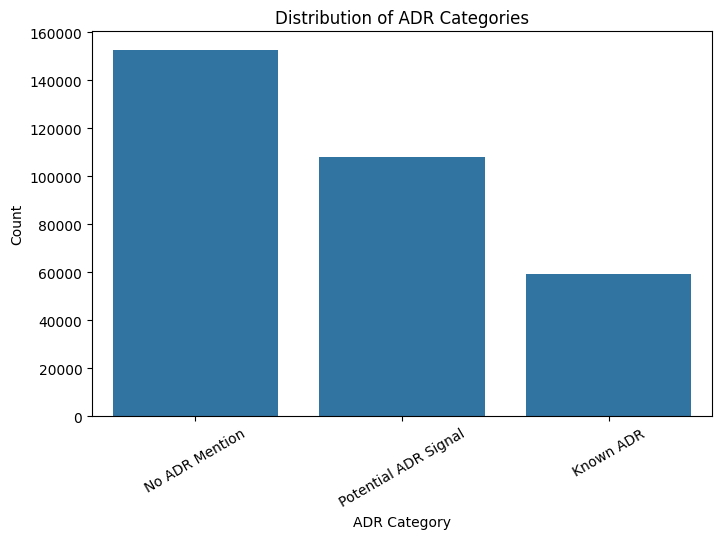

adr_category
No ADR Mention          152646
Potential ADR Signal    108061
Known ADR                59387
Name: count, dtype: int64
adr_category
No ADR Mention          0.477
Potential ADR Signal    0.338
Known ADR               0.186
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="adr_category",
    order=df["adr_category"].value_counts().index)

plt.title("Distribution of ADR Categories")
plt.xlabel("ADR Category")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

print(df["adr_category"].value_counts())
print(df["adr_category"].value_counts(normalize=True).round(3))

**Engineered-feature distributions**

Visualize the distributions of the engineered features to identify their ranges, patterns, and potential outliers.

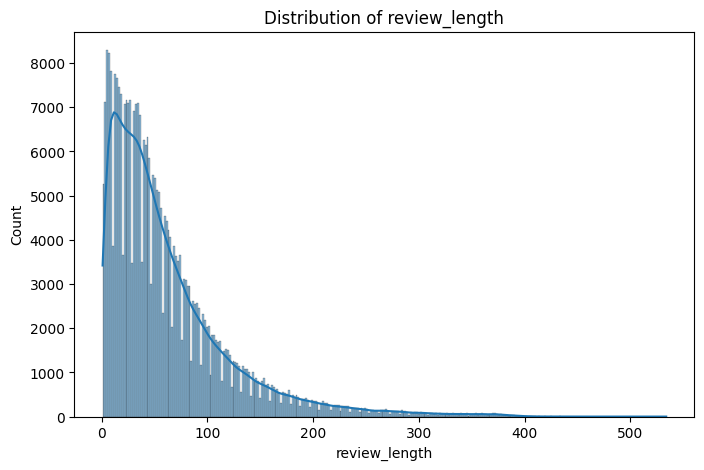

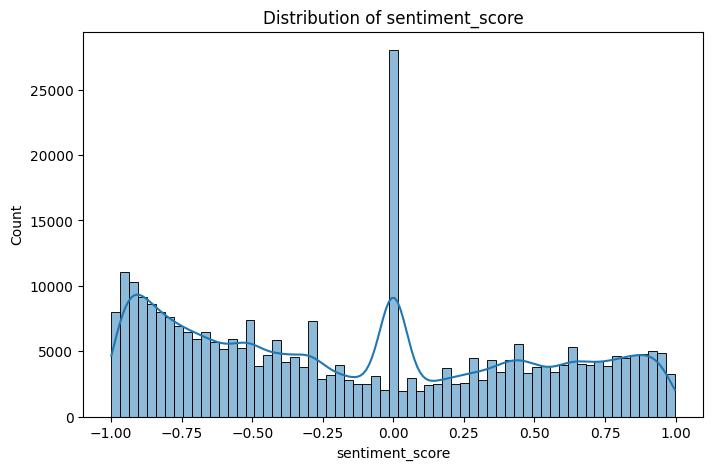

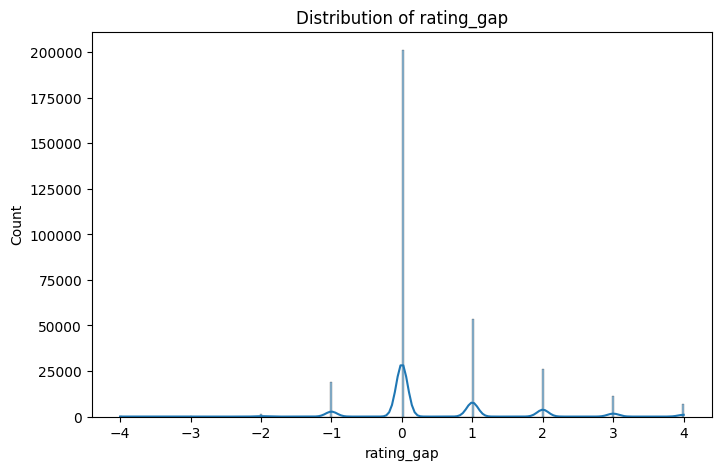

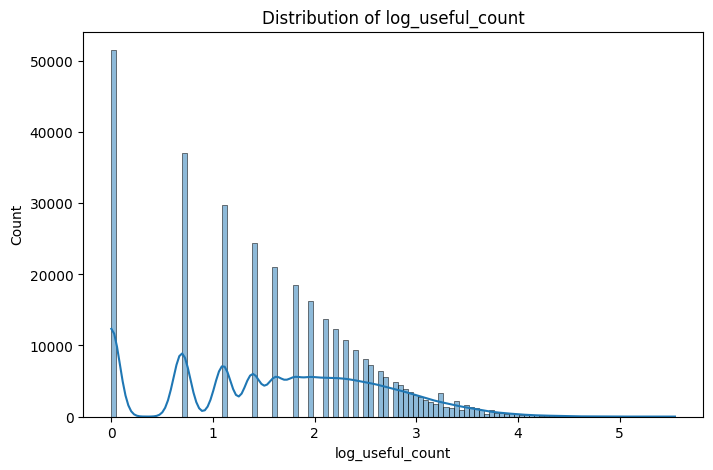

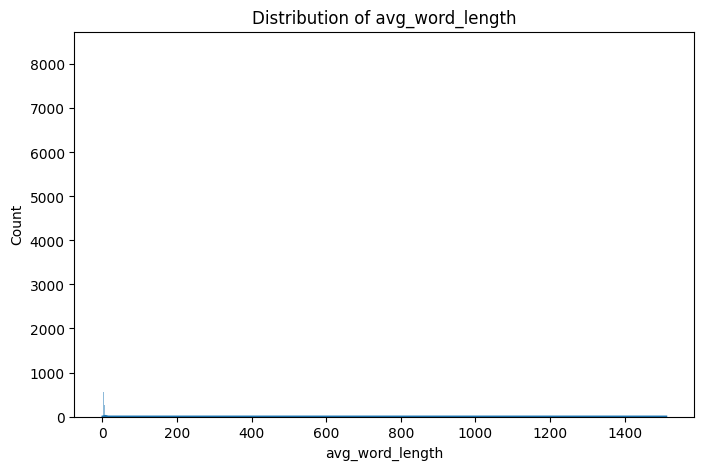

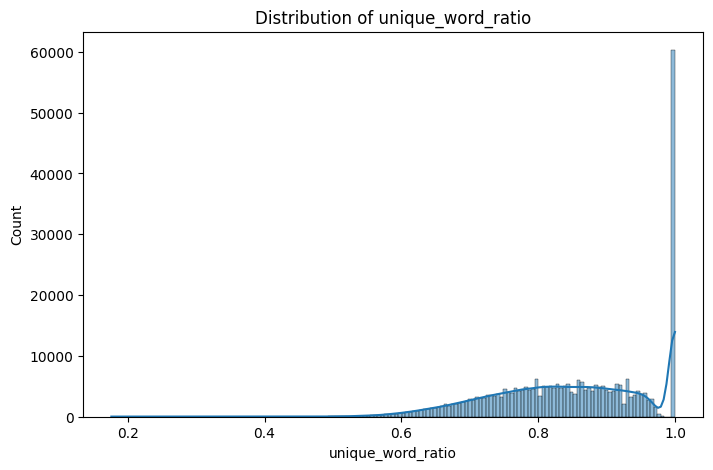

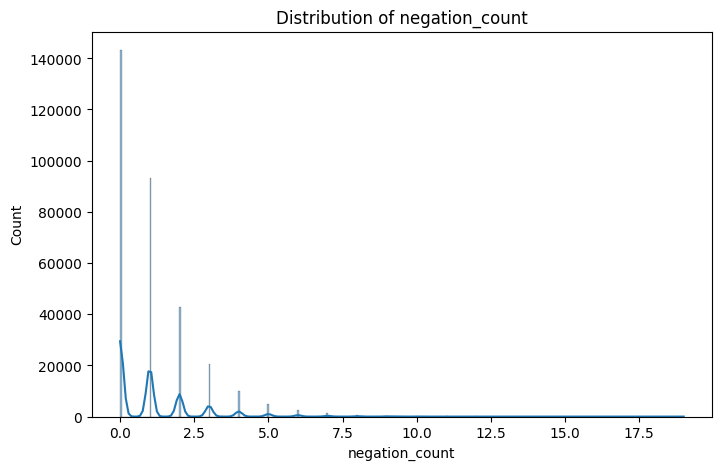

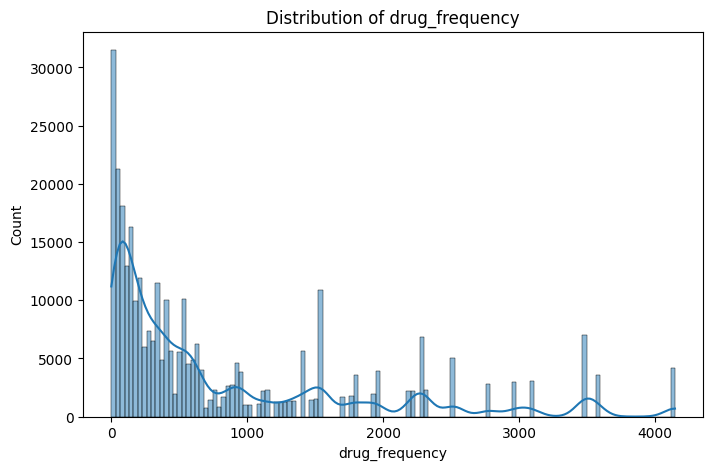

In [ ]:
eda_features = [
    "review_length",
    "sentiment_score",
    "rating_gap",
    "log_useful_count",
    "avg_word_length",
    "unique_word_ratio",
    "negation_count",
    "drug_frequency"]

for feature in eda_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[feature].dropna(), kde=True)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.show()

**Correlation HeatMap analysis**

Analyze correlations among the engineered numerical features to identify relationships and potential multicollinearity.

Do not include adr_category_encoded yet if you are moving encoding after EDA. Also exclude the ADR leakage features from the main modeling-focused heatmap

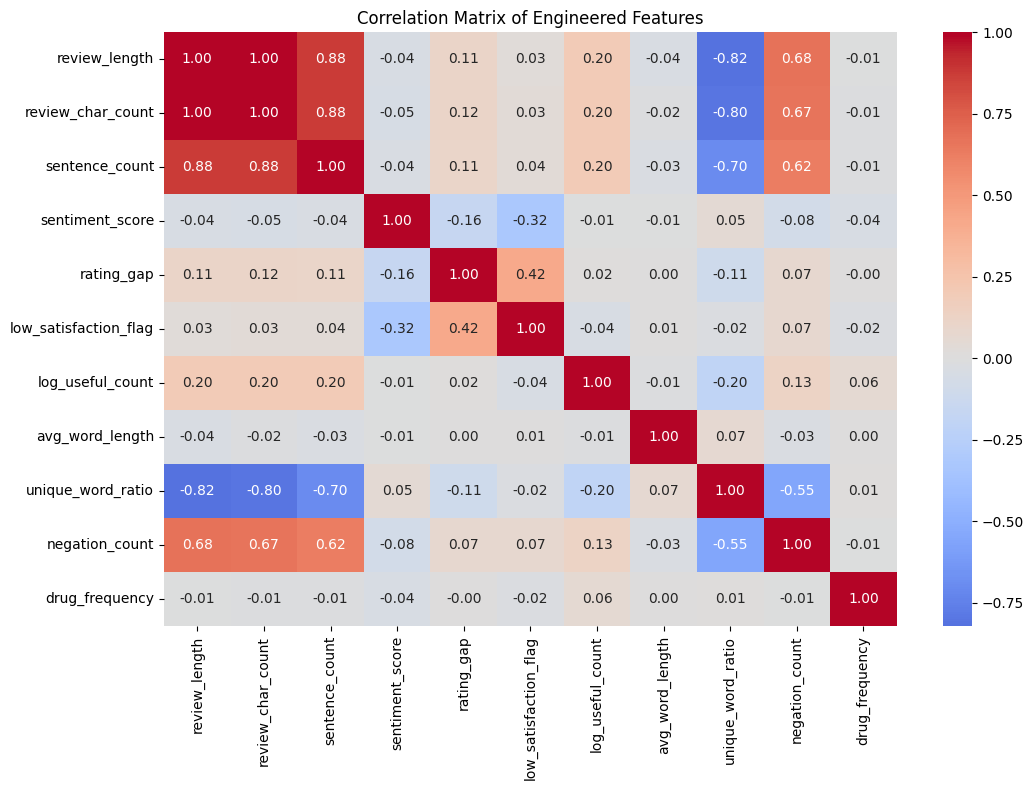

In [ ]:
correlation_features = [
    "review_length",
    "review_char_count",
    "sentence_count",
    "sentiment_score",
    "rating_gap",
    "low_satisfaction_flag",
    "log_useful_count",
    "avg_word_length",
    "unique_word_ratio",
    "negation_count",
    "drug_frequency"]

corr_matrix = df[correlation_features].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0)

plt.title("Correlation Matrix of Engineered Features")
plt.tight_layout()
plt.show()

# Bivariate Analysis



**ADR Category vs. Sentiment Score**

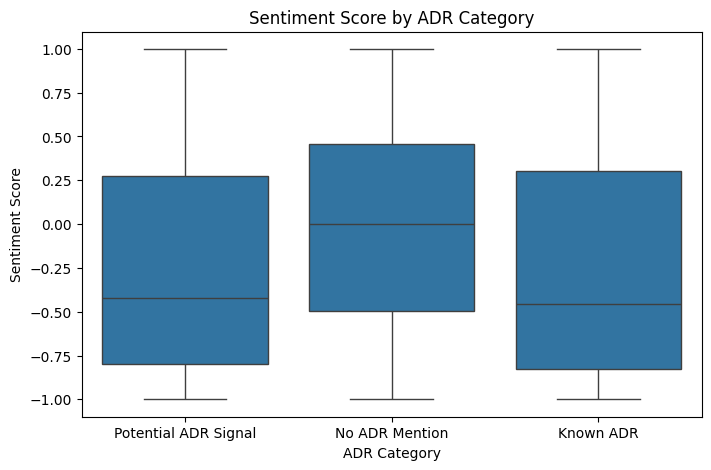

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot( data=df,x="adr_category",y="sentiment_score")

plt.title("Sentiment Score by ADR Category")
plt.xlabel("ADR Category")
plt.ylabel("Sentiment Score")
plt.show()

**ADR Category vs. Review Length**

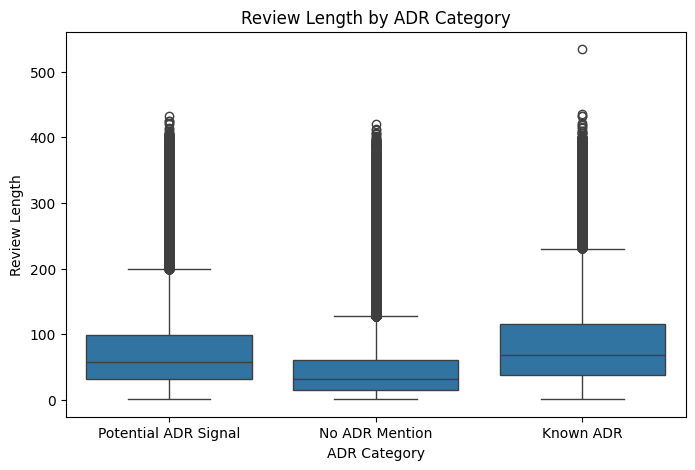

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df,x="adr_category", y="review_length")

plt.title("Review Length by ADR Category")
plt.xlabel("ADR Category")
plt.ylabel("Review Length")
plt.show()

**ADR Category vs. Satisfaction**

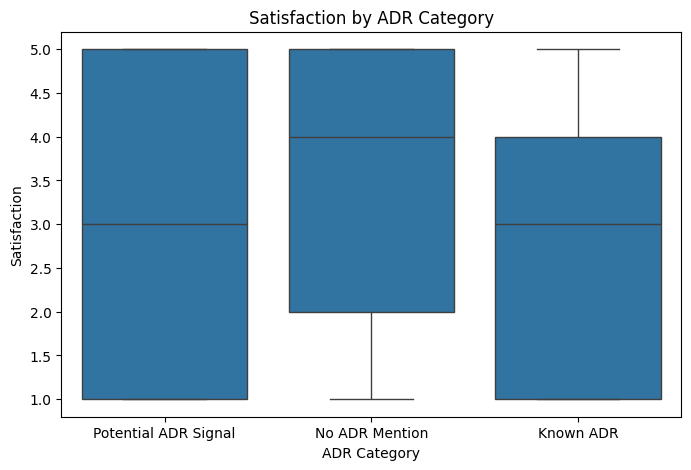

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="adr_category", y="satisfaction")

plt.title("Satisfaction by ADR Category")
plt.xlabel("ADR Category")
plt.ylabel("Satisfaction")
plt.show()

**ADR Category vs. Drug Frequency**

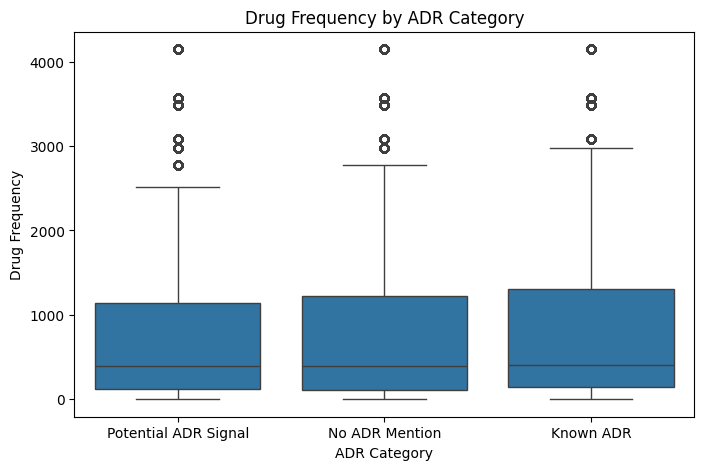

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="adr_category",
    y="drug_frequency"
)

plt.title("Drug Frequency by ADR Category")
plt.xlabel("ADR Category")
plt.ylabel("Drug Frequency")
plt.show()

**Encode the target variable**

Convert the categorical ADR labels into numerical values so they can be used by machine learning algorithms.


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["adr_category_encoded"] = label_encoder.fit_transform(df["adr_category"])

label_mapping = dict(zip(label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_)))

print("Target label mapping:", label_mapping)

print(df["adr_category"].value_counts())

print(df["adr_category_encoded"].value_counts().sort_index())

Target label mapping: {'Known ADR': np.int64(0), 'No ADR Mention': np.int64(1), 'Potential ADR Signal': np.int64(2)}
adr_category
No ADR Mention          152646
Potential ADR Signal    108061
Known ADR                59387
Name: count, dtype: int64
adr_category_encoded
0     59387
1    152646
2    108061
Name: count, dtype: int64


**Note:** because our target (adr_category_encoded) was created using adr_overlap_count and adr_novel_count so its not recommended to use these variables as predictor variables later as including them in the model would introduce target leakage, making the model appear more accurate than it would be on new data.

In [ ]:
# Features for modeling
feature_columns = [
    "review_nlp", # Pre-processed review text for TF-IDF vectorization
    "review_length",
    "review_char_count",
    "sentence_count",
    "sentiment_score",
    "rating_gap",
    "low_satisfaction_flag",
    "log_useful_count",
    "avg_word_length",
    "unique_word_ratio",
    "negation_count",
    "drug_frequency"
    ]

Now, setting up for model: Separate the dataset into predictor variables (X) and the target variable (y) for supervised machine learning. Split the data into training, validation, and testing sets using stratified sampling to preserve the class distribution and enable unbiased model evaluation.

In [ ]:
X = df[feature_columns]
y = df["adr_category_encoded"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y)

X_train, X_validation, y_train, y_validation = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train)

In [ ]:
print("Training features:", X_train.shape)
print("Validation features:", X_validation.shape)
print("Testing features :", X_test.shape)

print("Training labels  :", y_train.shape)
print("Validation labels:", y_validation.shape)
print("Testing labels   :", y_test.shape)

Training features: (204860, 12)
Validation features: (51215, 12)
Testing features : (64019, 12)
Training labels  : (204860,)
Validation labels: (51215,)
Testing labels   : (64019,)


**Saving Partitioned Data**

In [ ]:
# Training data
X_train.to_csv("/content/X_train.csv", index = False)
y_train.to_csv("/content/y_train.csv", index = False)

# Validation data
X_validation.to_csv("/content/X_validation.csv", index = False)
y_validation.to_csv("/content/y_validation.csv", index = False)

# Test data
X_test.to_csv("/content/X_test.csv", index = False)
y_test.to_csv("/content/y_test.csv", index = False)

# **MODELING**

**Preparation:**
- 64/16/20 train-validation-test set split
- TF-IDF vectorization of `reviews` and scaling of numerical predictors

**Linear models: SGD classifiers**
- `log_loss`, `hinge`, `perceptron` loss functions
- Performance evaluated using cross-validation and bootstrap macro F1 scores
- Regularization: `L1` and `L2` (only on the best performing model of the three models)
- Hyperparameter tuning: `alpha` (regularization strength)

**Deep learning: Deep neural network (DNN)**
- Early stopping based on validation loss to limit overfitting
- Validation set to compare macro F1 performance
- Regularization: `dropout`

**Model selection and final model evaluation**
- Best tuned linear classifier compared with the best DNN using the validation set, final model selected based on macro F1 score
- Test set used exclusively for confirming final model performance

**General notes / clarification:** Cross-validation and bootstrap sampling for the linear classifiers are conducted using the training set. The validation set is used to track macro F1 performance of the DNNs and for linear / DNN model comparison and selection.



# **Modeling Preparation**

**Importing Data and Results**  

Note: If necessary, saved data and previously generated modeling results are imported here to avoid re-running computationally expensive steps.

In [ ]:
# Training data
X_train = pd.read_csv("/content/X_train.csv")
y_train = pd.read_csv("/content/y_train.csv").squeeze("columns")

# Validation data
X_validation = pd.read_csv("/content/X_validation.csv")
y_validation = pd.read_csv("/content/y_validation.csv").squeeze("columns")

# Test data
X_test = pd.read_csv("/content/X_test.csv")
y_test = pd.read_csv("/content/y_test.csv").squeeze("columns")

**Review Text Imputation**  

In [ ]:
# Review text imputation, if necessary
X_train["review_nlp"] = X_train["review_nlp"].fillna("")
X_validation["review_nlp"] = X_validation["review_nlp"].fillna("")
X_test["review_nlp"] = X_test["review_nlp"].fillna("")

**Transforming Features**

In [ ]:
# Engineered numeric predictors
numeric = ["review_length", "review_char_count", "sentence_count",
           "sentiment_score", "rating_gap", "low_satisfaction_flag",
           "log_useful_count", "avg_word_length", "unique_word_ratio",
           "negation_count", "drug_frequency"]

# TF-IDF vectorization and scaling numeric predictors
transformation = ColumnTransformer([("tfidf", TfidfVectorizer(max_features = 5000), "review_nlp"),
                                    ("scale", StandardScaler(), numeric)], n_jobs = -1)

`TfidfVectorizer` (TF-IDF vectorization) will be used to transform `review_nlp` into numerical vectors compatible with the machine learning models. `StandardScaler` standardizes the engineered numeric features to a uniform scale, so features with larger values do not dominate.

# **Linear Classification Models**

**Feature Transformation and Classification Pipelines**

The three pipelines below make up the feature transformation and classification steps to be used in SGD classifier training and evaluation.

In [ ]:
# Log loss
sgdlog = Pipeline([("transformation", transformation),
                   ("sgdlog", SGDClassifier(loss = "log_loss", random_state = 42))])

In [ ]:
# Hinge loss
sgdhinge = Pipeline([("transformation", transformation),
                    ("sgdhinge", SGDClassifier(loss = "hinge", random_state = 42))])

In [ ]:
# Perceptron
sgdperc = Pipeline([("transformation", transformation),
                     ("sgdperc", SGDClassifier(loss = "perceptron", random_state = 42))])

**Cross-Validation**

In [ ]:
# Setting up 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

# Cross-validation scores (macro F1)
print("1: Log loss")
cvlog = cross_val_score(sgdlog, X_train, y_train, cv = cv, scoring = "f1_macro", n_jobs = -1)

print("2: Hinge loss")
cvhinge = cross_val_score(sgdhinge, X_train, y_train, cv = cv, scoring = "f1_macro", n_jobs = -1)

print("3: Perceptron")
cvperc = cross_val_score(sgdperc, X_train, y_train, cv = cv, scoring = "f1_macro", n_jobs = -1)

1: Log loss
2: Hinge loss
3: Perceptron


In [ ]:
# Average cross validation score list
avgcv = [cvlog.mean(), cvhinge.mean(), cvperc.mean()]

# Saving results
np.save("cvlog.npy", cvlog)
np.save("cvhinge.npy", cvhinge)
np.save("cvperc.npy", cvperc)
np.save("avgcv.npy", avgcv)

5-fold stratified cross-validation maintains class distribution across the folds, ensuring adequate representation of each class. This is especially important given the class imbalance in `adr_category`. The macro F1 score was selected as the scoring metric for this reason as well, in addition to its effectiveness for multiclass classification.

**Bootstrapping**  

In addition to cross-validation, bootstrap evaluation was used to further evaluate the three SGD classifiers. 20 bootstrap samples were created for each classifier, and then performance was measured on the out-of-bag rows with macro F1.

In [ ]:
# Models, bootstrap scores, classifier count
classifiers = [sgdlog, sgdhinge, sgdperc]
avgbs = []
allbs = []
count = 1

# Macro F1 function
def macrof1(y, ypred):
  return f1_score(y, ypred, average = "macro")

for c in classifiers:
  bs = []

  for i in range(20):
    # Bootstrap sample + training model
    Xbs, ybs = resample(X_train, y_train, random_state = i)
    c.fit(Xbs, ybs)

    # Out of bag rows
    outofbag = X_train.index.difference(Xbs.index)
    ypred = c.predict(X_train.loc[outofbag])
    mf1 = macrof1(y_train.loc[outofbag], ypred)

    # Bootstrap macro F1 score
    bs.append(mf1)

  # Bootstrap scores for each classifier
  allbs.append(bs)
  avgbs.append(np.mean(bs))

  print("Classifier", count, "completed.")
  count += 1

Classifier 1 completed.
Classifier 2 completed.
Classifier 3 completed.


In [ ]:
# Saving results
np.save("avgbs.npy", avgbs)
np.save("allbs.npy", allbs)

**Average Cross-Validation + Bootstrap Score Table**

In [ ]:
# Table to compare average CV + bootstrap macro F1 scores of each classifier
avgdf = pd.DataFrame({"Model": ["Log Loss", "Hinge Loss", "Perceptron"],
                      "Average CV Macro F1": avgcv,
                      "Average Bootstrap Macro F1": avgbs})

round(avgdf, 3)

,Model,Average CV Macro F1,Average Bootstrap Macro F1
0,Log Loss,0.679,0.678
1,Hinge Loss,0.707,0.709
2,Perceptron,0.684,0.708


**Distribution of Bootstrap Samples Plot**

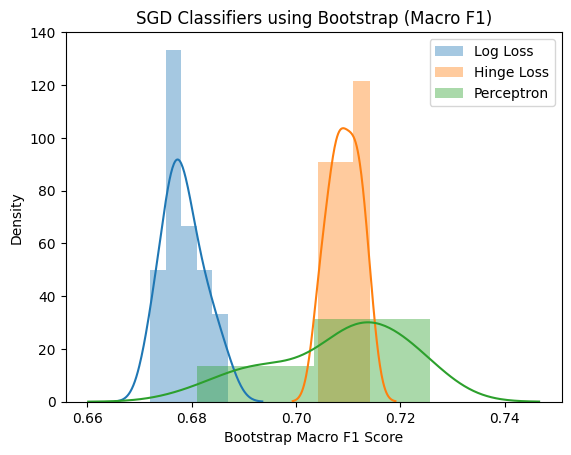

In [ ]:
# Bootstrap score dataframe
bsdf = pd.DataFrame(allbs)

# Plotting bootstrap samples
sns.distplot(bsdf.iloc[0], label = "Log Loss")
sns.distplot(bsdf.iloc[1], label = "Hinge Loss")
sns.distplot(bsdf.iloc[2], label = "Perceptron")

plt.title('SGD Classifiers using Bootstrap (Macro F1)')
plt.xlabel('Bootstrap Macro F1 Score')
plt.legend()
plt.show()

**Average Cross Validation Scores Barplot**

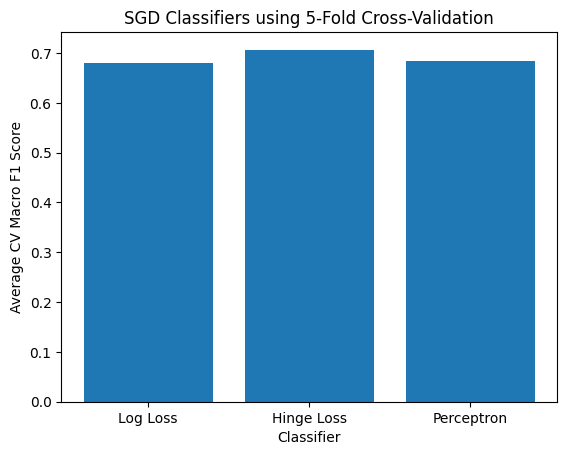

In [ ]:
plt.bar(avgdf["Model"], avgdf["Average CV Macro F1"])
plt.title("SGD Classifiers using 5-Fold Cross-Validation")

plt.xlabel("Classifier")
plt.ylabel("Average CV Macro F1 Score")
plt.show()

From the average score comparison table, the bootstrap score distribution plot, and the cross validation barplot, the hinge loss SGD classifier is selected as the best performing linear model, and is therefore subject to hyperparameter tuning for further refinement. Cross-validation macro F1 (0.707) and bootstrap macro F1 (0.709) were the highest observed. Perceptron also exhibited a high bootstrap score (0.708). but distribution is significantly wider, indicating higher variability.


## **Regularization and Hyperparameter Tuning**

`L1` and `L2` regularization are tested using the range of alpha values below. 5-fold cross validation is performed with macro F1 for scoring. The combination of regularization method and alpha value producing the highest macro F1 score is then selected as the best performing tuned linear classifier.

In [ ]:
# Regularization strength (selected alpha values)
alphas = [0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]

**Hinge Loss L1 Regularization**



In [ ]:
# L1 results
l1results = []

for a in alphas:
  # Feature transformation + building L1 classifier
  l1clf = Pipeline([("transformation", transformation),
                      ("l1", SGDClassifier(loss = "hinge", penalty = "l1",
                                                alpha = a, random_state = 42))])

  # 5-fold cross validation
  l1cv = cross_val_score(l1clf, X_train, y_train, cv = 5,
                         scoring = "f1_macro", n_jobs = -1).mean()
  print("Finished 5-fold CV, alpha = %f" % a)

  # Adding average macro F1 scores to results list
  l1results.append(l1cv)

Finished 5-fold CV, alpha = 0.000010
Finished 5-fold CV, alpha = 0.000100
Finished 5-fold CV, alpha = 0.001000
Finished 5-fold CV, alpha = 0.010000
Finished 5-fold CV, alpha = 0.100000
Finished 5-fold CV, alpha = 1.000000
Finished 5-fold CV, alpha = 10.000000
Finished 5-fold CV, alpha = 100.000000
Finished 5-fold CV, alpha = 1000.000000


In [ ]:
# Saving results
np.save("l1results.npy", l1results)

**Hinge Loss L2 Regularization**

In [ ]:
# L2 results
l2results = []

for a in alphas:
  # Feature transformation + building L2 classifier
  l2clf = Pipeline([("transformation", transformation),
                      ("l2", SGDClassifier(loss = "hinge", penalty = "l2",
                                                alpha = a, random_state = 42))])

  # 5-fold cross validation
  l2cv = cross_val_score(l2clf, X_train, y_train, cv = 5,
                         scoring = "f1_macro", n_jobs = -1).mean()
  print("Finished 5-fold CV, alpha = %f" % a)

  # Adding average macro F1 scores to results list
  l2results.append(l2cv)

Finished 5-fold CV, alpha = 0.000010
Finished 5-fold CV, alpha = 0.000100
Finished 5-fold CV, alpha = 0.001000
Finished 5-fold CV, alpha = 0.010000
Finished 5-fold CV, alpha = 0.100000
Finished 5-fold CV, alpha = 1.000000
Finished 5-fold CV, alpha = 10.000000
Finished 5-fold CV, alpha = 100.000000
Finished 5-fold CV, alpha = 1000.000000


In [ ]:
# Saving results
np.save("l2results.npy", l2results)

**L1 / L2 Regularization Macro F1 Comparison Table**

In [ ]:
regdf = pd.DataFrame({"Alpha": alphas,
                      "Hinge L1": l1results,
                      "Hinge L2": l2results})
round(regdf, 5)

,Alpha,Hinge L1,Hinge L2
0,0.00001,0.76343,0.74767
1,0.00010,0.73360,0.70567
2,0.00100,0.60790,0.58591
3,0.01000,0.34904,0.39930
4,0.10000,0.36738,0.38284
5,1.00000,0.21527,0.43785
6,10.00000,0.20587,0.41472
7,100.00000,0.20587,0.39414
8,1000.00000,0.20587,0.24930


**L1 / L2 Regularization Macro F1 Plot**

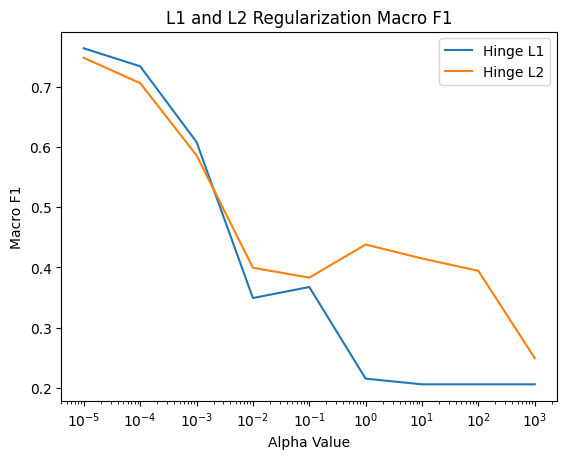

In [ ]:
# X-axis values
xaxis = regdf["Alpha"]

# Plotting L1 and L2 Regularization Macro F1
sns.lineplot(x = xaxis, y = regdf["Hinge L1"], label = "Hinge L1")
sns.lineplot(x = xaxis, y = regdf["Hinge L2"], label = "Hinge L2")

plt.title("L1 and L2 Regularization Macro F1")
plt.xscale("log")
plt.xlabel("Alpha Value")
plt.ylabel("Macro F1")
plt.show()

From the L1 / L2 regularization comparison table and plots, `L1` with `alpha = 0.00001` achieved the best performance (average macro F1 = 0.763). In general, regardless of regularization method, general performance appears to worsen with higher `alpha` values.

The selected linear model, then, for comparison with the selected deep neural network model, is the hinge-loss SGD classifier with `L1` regularization and `alpha = 0.00001`.

# **Deep Neural Network (DNN) Model**

Along with the linear classifiers, deep neural networks (DNN) are developed to serve as their non-linear counterparts. Depending on initial model performance, a regularized model is also developed to reduce overfitting.

**Transforming Features**

In [ ]:
# Transforming features for DNN
transformationdl = ColumnTransformer([("tfidf", TfidfVectorizer(max_features = 5000), "review_nlp"),
                                      ("scale", StandardScaler(), numeric)], n_jobs = -1)

# Transforming training and validation data
X_traindl = transformationdl.fit_transform(X_train)
X_validationdl = transformationdl.transform(X_validation)

`TfidfVectorizer` (TF-IDF vectorization) is used to transform `reviews` into numerical vectors compatible with the deep learning model. `StandardScaler` standardizes the engineered numeric features to a uniform scale, so features with larger values do not dominate.

## **Initial DNN (Sequential) Model**

**Building the Initial Model**

The initial DNN is built using Keras' `Sequential` model, which involves grouping into a linear stack of layers. These are made up of an input layer and 3 hidden dense layers with 128, 64, and 32 neurons (and using the ReLU activation function). The `softmax` activation function in the output layer creates class probabilities.

In [ ]:
# Initializing the model
seqmodel = keras.Sequential()

# Adding layers
seqmodel.add(keras.layers.Input(shape = (X_traindl.shape[1],), sparse = True))
seqmodel.add(keras.layers.Dense(128, activation = "relu"))
seqmodel.add(keras.layers.Dense(64, activation = "relu"))
seqmodel.add(keras.layers.Dense(32, activation = "relu"))
seqmodel.add(keras.layers.Dense(3, activation = "softmax"))

In [ ]:
# Model contents
seqmodel.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       641,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 651,971 (2.49 MB)

 Trainable params: 651,971 (2.49 MB)

 Non-trainable params: 0 (0.00 B)

**Model Compilation**

In [ ]:
seqmodel.compile(optimizer = "adam",
                 loss = "sparse_categorical_crossentropy",
                 metrics = ["accuracy"])

**Training the Initial Model**

Early stopping tracks `val_loss` (validation loss) and stops training at `patience = 3` or 3 consecutive epochs without improvement. The weights from the epoch with the lowest validation loss are then restored.

In [ ]:
# Early stopping
callback = keras.callbacks.EarlyStopping(monitor = "val_loss",
                                         patience = 3, restore_best_weights = True)

# Model training
history = seqmodel.fit(X_traindl, y_train,
                       validation_data = (X_validationdl, y_validation),
                       batch_size = 256, epochs = 18, callbacks = [callback])

Epoch 1/18
801/801 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.7745 - loss: 0.5132 - val_accuracy: 0.8225 - val_loss: 0.4172
Epoch 2/18
801/801 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.8432 - loss: 0.3725 - val_accuracy: 0.8370 - val_loss: 0.3866
Epoch 3/18
801/801 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.8748 - loss: 0.3049 - val_accuracy: 0.8447 - val_loss: 0.3821
Epoch 4/18
801/801 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.9060 - loss: 0.2366 - val_accuracy: 0.8470 - val_loss: 0.3998
Epoch 5/18
801/801 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.9332 - loss: 0.1732 - val_accuracy: 0.8504 - val_loss: 0.4463
Epoch 6/18
801/801 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.9537 - loss: 0.1244 - val_accuracy: 0.8493 - val_loss: 0.5241


- Lowest validation loss at epoch 3
- Validation loss from 4-6 continually grew (3 consecutive epochs), significantly at epoch 6

**Initial Model Performance**

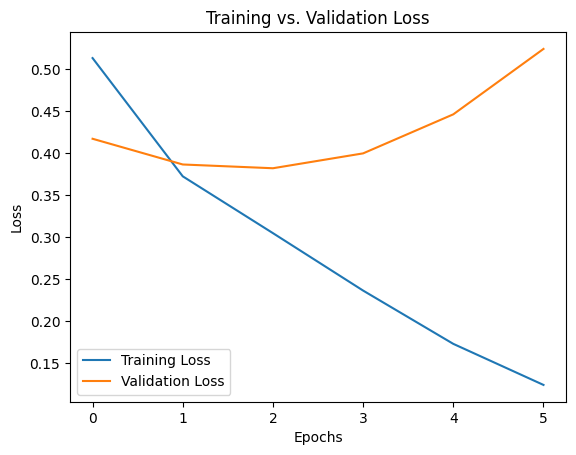

In [ ]:
# Training Loss vs. Validation Loss Plot
plt.plot(history.history["loss"], label = "Training Loss")
plt.plot(history.history["val_loss"], label = "Validation Loss")

plt.title("Training vs. Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

Training loss decreased throughout training, while validation loss hit a minimum at 3 epochs (shown as 2 in the plot as indexing begins at 0) and then increased, suggesting overfitting. Dropout regularization may improve robustness and generalization ability.

In [ ]:
# Predictions on validation set
ypredvalraw = seqmodel.predict(X_validationdl)
ypredval = np.argmax(ypredvalraw, axis = 1)

# Macro F1 score
macrof1dl = f1_score(y_validation, ypredval, average = "macro")
print("Initial DNN macro F1 score:", round(macrof1dl, 3))

1601/1601 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
Initial DNN macro F1 score: 0.808


- `ypredvalraw` - Raw predicted probabilities
- `ypredval` - Final predicted class label
- Initial deep learning model macro F1: 0.808

## **DNN Model with Dropout Regularization**

**Building the Dropout Model**

The general model architecture remains the same, but `Dropout(0.3)` is added after the first and second hidden layers, in which 30% of neurons are 'dropped out' during training to limit overfitting.

In [ ]:
# Initializing model (with dropout)
seqmodeldropout = keras.Sequential()

# Adding layers
seqmodeldropout.add(keras.layers.Input(shape = (X_traindl.shape[1],), sparse = True))
seqmodeldropout.add(keras.layers.Dense(128, activation = "relu"))
seqmodeldropout.add(keras.layers.Dropout(0.3))
seqmodeldropout.add(keras.layers.Dense(64, activation = "relu"))
seqmodeldropout.add(keras.layers.Dropout(0.3))
seqmodeldropout.add(keras.layers.Dense(32, activation = "relu"))
seqmodeldropout.add(keras.layers.Dense(3, activation = "softmax"))

**Model Compilation**

In [ ]:
seqmodeldropout.compile(optimizer = "adam",
                 loss = "sparse_categorical_crossentropy",
                 metrics = ["accuracy"])

**Training the Dropout Model**

In [ ]:
# Early stopping
callbackdropout = keras.callbacks.EarlyStopping(monitor = "val_loss",
                                         patience = 3, restore_best_weights = True)

# Model training
historydropout = seqmodeldropout.fit(X_traindl, y_train,
                       validation_data = (X_validationdl, y_validation),
                       batch_size = 256, epochs = 18, callbacks = [callbackdropout])

Epoch 1/18
801/801 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.7551 - loss: 0.5525 - val_accuracy: 0.8188 - val_loss: 0.4209
Epoch 2/18
801/801 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.8304 - loss: 0.4006 - val_accuracy: 0.8323 - val_loss: 0.3957
Epoch 3/18
801/801 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.8568 - loss: 0.3433 - val_accuracy: 0.8416 - val_loss: 0.3790
Epoch 4/18
801/801 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.8788 - loss: 0.2946 - val_accuracy: 0.8484 - val_loss: 0.3779
Epoch 5/18
801/801 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.8966 - loss: 0.2560 - val_accuracy: 0.8504 - val_loss: 0.3778
Epoch 6/18
801/801 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.9116 - loss: 0.2215 - val_accuracy: 0.8515 - val_loss: 0.3987
Epoch 7/18
801/801 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.9230 - loss: 0.1954 - val_accuracy: 0.8520 - val_loss: 0.4199
Epoch 8/18
801/801 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.9309 - loss: 0.1773 - 

Trained for 8 epochs; validation loss improved from 1-5 (5 is best) then grew afterwards, suggesting that overfitting was reduced, at least, in comparison to the initial model.

**Dropout Model Performance**

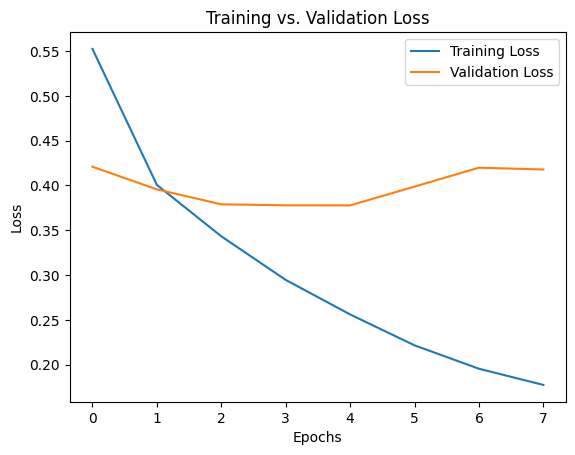

In [ ]:
# Training Loss vs. Validation Loss Plot
plt.plot(historydropout.history["loss"], label = "Training Loss")
plt.plot(historydropout.history["val_loss"], label = "Validation Loss")

plt.title("Training vs. Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

The plot illustrates that training loss decreased throughout, while validation loss also decreased until 5 epochs (shown as 4 in the plot as indexing begins at 0). Loss also remained fairly consistent throughout, as opposed to the initial model.

In [ ]:
# Predictions on validation set
ypredvaldropoutraw = seqmodeldropout.predict(X_validationdl)
ypredvaldropout = np.argmax(ypredvaldropoutraw, axis = 1)

# Macro F1 score
macrof1dldropout = f1_score(y_validation, ypredvaldropout, average = "macro")
print("Dropout DNN model macro F1 score:", round(macrof1dldropout, 3))

1601/1601 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
Dropout DNN model macro F1 score: 0.816


**DNN Model Comparison**

In [ ]:
# Table to compare DNN models (initial and with dropout)
comparisondl = pd.DataFrame({"Model": ["Initial", "Dropout"],
                             "Macro F1": [macrof1dl, macrof1dldropout]})
round(comparisondl, 3)

,Model,Macro F1
0,Initial,0.808
1,Dropout,0.816


The dropout DNN model achieved a macro F1 score of 0.816. This is an improvement in predictive performance compared to the initial model, albeit marginal. Training and loss validation patterns do indicate, however, that regularization reduced overfitting.

Ultimately, for model comparison with the best performing linear model, the DNN with dropout regularization is selected.

# **Model Comparison**

- Comparing the performance of the best-performing linear classifier and the best-performing DNN model  
- The main evaluation metric is Macro F1, but macro recall, macro precision, and accuracy are also taken into consideration
- The better performing model is chosen as the final model.

Classifiers selected for comparison:
- Linear model: Hinge loss SGD, with `L1` regularization and `alpha = 0.00001`
- DNN model: Deep neural network with dropout regularization

In [ ]:
# Feature transformation, building and fitting the selected hinge loss SGD classifier
tunedhinge = Pipeline([("transformation", transformation),
                      ("sgdhinge", SGDClassifier(loss = "hinge", penalty = "l1",
                                                alpha = 0.00001, random_state = 42))])
tunedhinge.fit(X_train, y_train)

Pipeline(steps=[('transformation',
                 ColumnTransformer(n_jobs=-1,
                                   transformers=[('tfidf',
                                                  TfidfVectorizer(max_features=5000),
                                                  'review_nlp'),
                                                 ('scale', StandardScaler(),
                                                  ['review_length',
                                                   'review_char_count',
                                                   'sentence_count',
                                                   'sentiment_score',
                                                   'rating_gap',
                                                   'low_satisfaction_flag',
                                                   'log_useful_count',
                                                   'avg_word_length',
                                                   'unique_word_ratio',
                                                   'negation_count',
                                                   'drug_frequency'])])),
                ('sgdhinge',
                 SGDClassifier(alpha=1e-05, penalty='l1', random_state=42))])

**Best Linear Classifier (Tuned Hinge) Performance**

In [ ]:
# Predictions on validation set
ypredtunedhinge = tunedhinge.predict(X_validation)

# Macro F1 score
macrof1tunedhinge = f1_score(y_validation, ypredtunedhinge, average = "macro")
print("Tuned hinge macro F1 score:", round(macrof1tunedhinge, 3))

Tuned hinge macro F1 score: 0.758


**Model Comparison**

In [ ]:
# Classification report - tuned hinge
print(classification_report(y_validation, ypredtunedhinge))

              precision    recall  f1-score   support

           0       0.67      0.54      0.60      9502
           1       0.91      0.93      0.92     24423
           2       0.73      0.78      0.75     17290

    accuracy                           0.81     51215
   macro avg       0.77      0.75      0.76     51215
weighted avg       0.81      0.81      0.81     51215



In [ ]:
# Classification report - DNN with dropout
print(classification_report(y_validation, ypredvaldropout))

              precision    recall  f1-score   support

           0       0.73      0.68      0.71      9502
           1       0.94      0.94      0.94     24423
           2       0.79      0.82      0.80     17290

    accuracy                           0.85     51215
   macro avg       0.82      0.81      0.82     51215
weighted avg       0.85      0.85      0.85     51215



In [ ]:
# Macro F1 comparison table
modelcomparison = pd.DataFrame({"Model": ["Tuned Hinge", "DNN with Dropout"],
                                "Macro F1": [macrof1tunedhinge, macrof1dldropout]})
round(modelcomparison, 3)

,Model,Macro F1
0,Tuned Hinge,0.758
1,DNN with Dropout,0.816


The deep neural network model with dropout regularization achieved the higher macro F1 score (`0.816`) as well as all other metrics when evaluated on the validation set (as indicated by the classification reports), suggesting that it has better predictive ability.

In congruence with the selection criteria established earlier, this model is chosen as the final model, and its performance will be measured on the held-out test set, to ensure that results align with those seen on the validation set.

# **Final Model Evaluation**

Final Model: Deep neural network model with dropout regularization.

**Transforming Test Data**

In [ ]:
X_testdl = transformationdl.transform(X_test)

**Final Model Performance on Test Data**

In [ ]:
# Predictions on test set
ypredtestraw = seqmodeldropout.predict(X_testdl)
ypredtest = np.argmax(ypredtestraw, axis = 1)

# Macro F1 score
macrof1test = f1_score(y_test, ypredtest, average = "macro")
print("Final model macro F1 score:", round(macrof1test, 3))

2001/2001 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
Final model macro F1 score: 0.816


In [ ]:
# Classification report
print(classification_report(y_test, ypredtest))

              precision    recall  f1-score   support

           0       0.74      0.68      0.71     11878
           1       0.94      0.94      0.94     30529
           2       0.79      0.81      0.80     21612

    accuracy                           0.85     64019
   macro avg       0.82      0.81      0.82     64019
weighted avg       0.85      0.85      0.85     64019



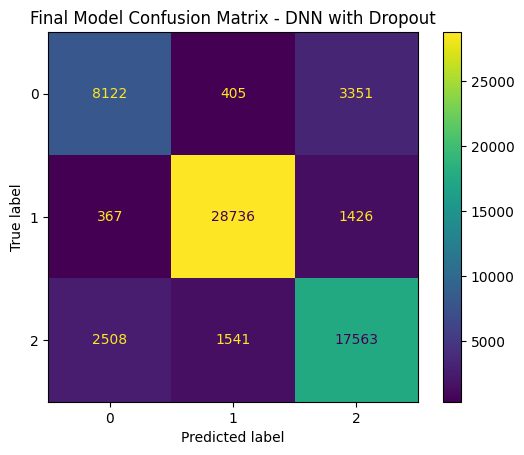

In [ ]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, ypredtest)
plt.title("Final Model Confusion Matrix - DNN with Dropout")
plt.show()

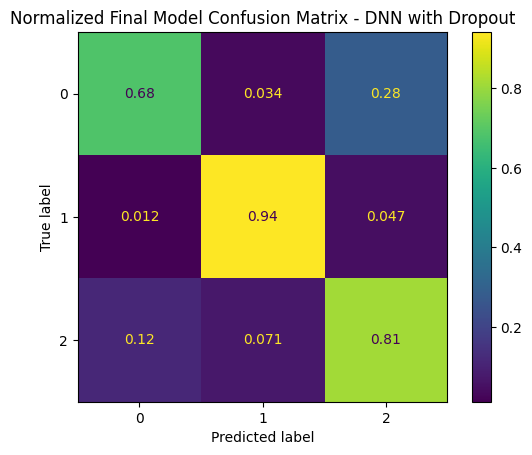

In [ ]:
# Normalized confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, ypredtest, normalize = "true")
plt.title("Normalized Final Model Confusion Matrix - DNN with Dropout")
plt.show()

**Shapley Additive Explanations (SHAP)**

In [ ]:
# Feature names (numerical and word)
tfidfnames = transformationdl.named_transformers_["tfidf"].get_feature_names_out()
featurenames = np.concatenate((tfidfnames, np.array(numeric)))

print(len(featurenames))

5011


In [ ]:
np.random.seed(24)

# Background data array
backgroundindices = np.random.choice(X_traindl.shape[0], 100, replace = False)
background = X_traindl[backgroundindices].toarray()

# SHAP explainer
explainer = shap.GradientExplainer(seqmodeldropout, background)

# Test data sample
sampleindices = np.random.choice(X_testdl.shape[0], 100, replace = False)
samples = X_testdl[sampleindices].toarray()

# SHAP values + average absolute SHAP values
shaps = explainer.shap_values(samples)
averageshaps = np.mean(np.abs(shaps), axis = 2)

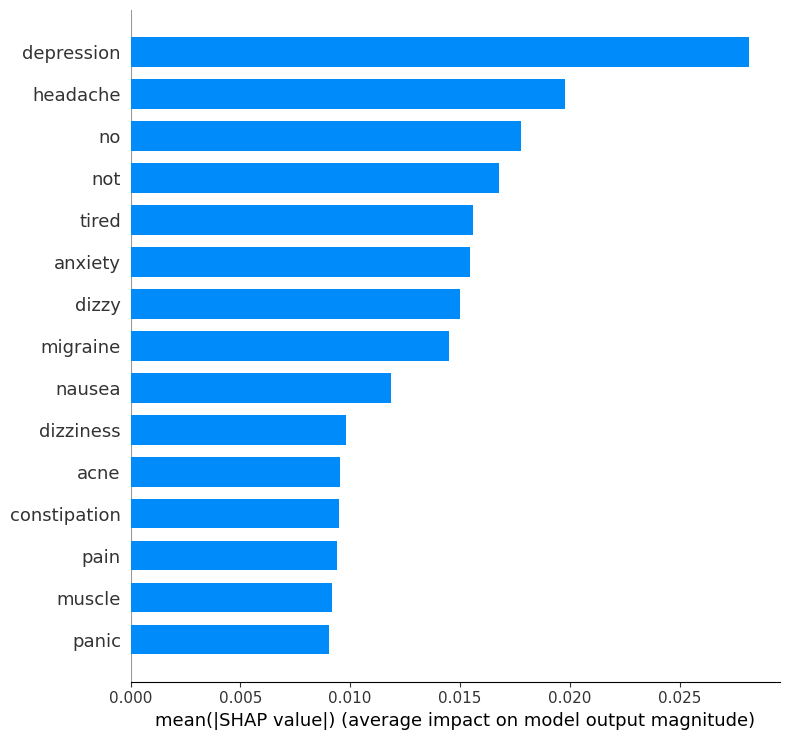

In [ ]:
# Most important words - Bar plot
wordnum = len(tfidfnames)
wordshaps = averageshaps[:, :wordnum]
wordsamples = samples[:, :wordnum]

shap.summary_plot(wordshaps, wordsamples, feature_names = tfidfnames,
                  max_display = 15, plot_type = "bar")

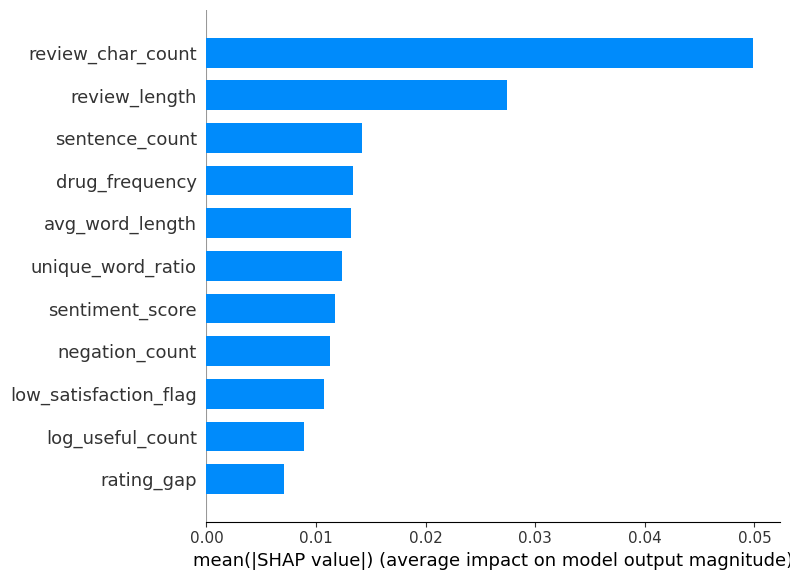

In [ ]:
# Numeric features, ranked by importance - Bar plot
numshaps = averageshaps[:, -len(numeric):]
numsamples = samples[:, -len(numeric):]

shap.summary_plot(numshaps, numsamples, feature_names = numeric,
                  max_display = 15, plot_type = "bar")

**Short Discussion**

The final model (deep neural network with dropout) seems to generalize well, the validation and test set results align. With a test Macro F1 score of 0.816, performance may be deemed 'fairly strong'.

Confusion matrix results:
- Classified majority of observations in all the labels
- Strongest in class 1 (no ADR mention) - 28,736 (94%) classified correctly
- More error with Known ADR and Potential ADR Signal - 3,351 (28%) known ADR classified as potential ADR, and 2,508(12%) potential ADR classified as known ADR.

Potentially, this is the result of textual similarities in both Known and Potential ADR, and so more difficult to distinguish. Future refinements could introduce advancd NLP techniques, and additional feature engineering.

Feature importance:
- 15 most important words: `depression`, `headache`, `no`, `not`, `tired`, `anxiety`, `dizzy`, `migraine`, `nausea`, `dizziness`, `acne`, `constipation`, `pain`, `muscle`, `panic`. All of these terms describe symptoms or negative experiences typically associated with ADRs (no ADR mention, considering the negation terms).
- Numeric features, ranked by importance: `review_char_count`, `review_length`, `sentence_count`, `drug_frequency`, `average_word_length`, `unique_word_ratio`, `sentiment_score`, `negation_count`, `low_satisfaction_flag`, `log_useful_count`, `rating_gap`.  So, the length and general structure of the reviews appear to have greater influence.
